# Calibrated to Injustice and Accurately Unjust: Clinical AI Has Been Predicting the Wrong World

This notebook reproduces the **primary MIMIC-IV analysis**: the Four-Configuration Logical
Asymmetry design, the Therapeutic-capability Reference Model (TRM), Clinical-Regime Decomposition, and the
calibration analysis 

| Quantity | Method |
|---|---|
| Quartile AUROC + 95% CI | AUROC on **pooled out-of-fold** predictions; **bootstrap ×2000** percentile CI |
| Race AUROC + 95% CI | pool OOF predictions → one AUROC; **bootstrap ×1000** percentile CI |
| Pairwise AUROC comparison | **DeLong** on pooled patient-level predictions, Bonferroni within axis |
| Uniformity trend (all 4 configs) | permutation **max-JT** over all orderings, **1000** permutations, on **true per-fold AUROCs** |
| Degradation trend (Config 3) | **directional JT**, fixed Q1→Q4, **10 000** permutations, on **true per-fold AUROCs** |
| Monotonicity descriptor | **Spearman ρ** of the four pooled AUROC point estimates vs rank 1–4 |
| SOFA balance | **Kruskal–Wallis** across Q1–Q4 |
| Calibration curves | per-fold **Platt** scaling, pooled predictions, 8 quantile bins |
| ECE | per-fold Platt scaling, pooled predictions, **10 equal-width** bins |
| Clinical-Regime decomposition | **pooled** per-SOFA-bin AUROC + bootstrap CI, Q1 vs Q4 |

**Race analysis uses four groups — White, Black, Hispanic/Latino, Asian ("Other" is excluded)** —





## 1 · Setup — imports and global configuration

In [2]:
import os, warnings, importlib, subprocess, sys

# --- optional auto-install (only runs if a package is missing) ---------------
for pkg in ['xgboost', 'sklearn', 'pandas', 'numpy', 'scipy', 'statsmodels',
            'matplotlib', 'openpyxl']:
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                               'scikit-learn' if pkg == 'sklearn' else pkg])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations, permutations as iperms

from scipy import stats
from scipy.stats import kruskal, spearmanr
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
import xgboost as xgb

# SHAP is optional (feature-importance figure only). Load defensively.
try:
    import shap
except Exception:
    shap = None

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.3, 'figure.dpi': 130})
print('Environment ready.')


Environment ready.


## 2 · Data paths
Point these at your local mouthcare and turning `.pkl` folders.

In [ ]:
MOUTHCARE_FOLDER = r""      
TURNING_FOLDER   = r""    
OUTPUT_FOLDER    = "figures"
OUTPUT_EXCEL     = "mortality_results.xlsx"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

for label, folder in [('Mouthcare', MOUTHCARE_FOLDER), ('Turning', TURNING_FOLDER)]:
    print(f'{label:10s}: {"OK " if os.path.exists(folder) else "NOT FOUND"}  {folder}')


Mouthcare : OK   C:\Users\nacha\Downloads\drive-download-20260221T132021Z-1-001\mouthcare
Turning   : OK   C:\Users\nacha\Downloads\drive-download-20260221T132021Z-1-001\turningcare


## 3 · Constants and feature definitions

**37 predictor features** = 6 SOFA organ-system subscores (LODS proxy) + 31 labs/vitals extremes
(APACHE-III proxy). The SOFA **total** is used only for severity stratification and is never a
feature. Care frequency and race are never features.

In [4]:
PATIENT_ID = 'stay_id'
MORTALITY  = 'hospital_expire_flag'
FREQ_COL   = 'average_item_interval'    # mean interval (h) between documented care events
SOFA_COL   = 'SOFA'                      # TOTAL SOFA — stratification only, never a feature
RACE_COL   = 'race'
RANDOM_STATE = 42

QUARTILES       = ['Q1', 'Q2', 'Q3', 'Q4']          # Q1 = most frequent care, Q4 = least
SEVERITY_LABELS = ['Low', 'Medium', 'High']
SEVERITY_CUTS   = [-1, 6, 11, 999]                   # Low 0-6, Medium 7-11, High >=12

# 37 model features (SOFA total EXCLUDED) ------------------------------------
LODS_COLS   = ['respiration', 'cardiovascular', 'liver', 'coagulation', 'renal', 'cns']
APSIII_COLS = ['heart_rate_min','heart_rate_max','heart_rate_mean',
               'mbp_min','mbp_max','mbp_mean',
               'temperature_min','temperature_max','temperature_mean',
               'resp_rate_min','resp_rate_max','resp_rate_mean',
               'hematocrit_min','hematocrit_max','wbc_min','wbc_max',
               'creatinine_min','creatinine_max','bun_min','bun_max',
               'sodium_min','sodium_max','albumin_min','albumin_max',
               'bilirubin_total_min','bilirubin_total_max',
               'glucose_min','glucose_max','bicarbonate_min','bicarbonate_max','gcs_min']
FEATURE_COLS = LODS_COLS + APSIII_COLS
assert len(FEATURE_COLS) == 37

# Race consolidation. 'Other' and unknown/declined are NOT used in the paper's race
# analysis (heterogeneous catch-all / uninformative), so only the four analysis groups
# below are reported and tested (six pairwise comparisons).
RACE_MAP = {
    'WHITE':'White','WHITE - OTHER EUROPEAN':'White','WHITE - RUSSIAN':'White',
    'WHITE - BRAZILIAN':'White','WHITE - EASTERN EUROPEAN':'White','PORTUGUESE':'White',
    'BLACK/AFRICAN AMERICAN':'Black','BLACK/AFRICAN':'Black','BLACK/CAPE VERDEAN':'Black',
    'BLACK/CARIBBEAN ISLAND':'Black',
    'HISPANIC OR LATINO':'Hispanic/Latino','HISPANIC/LATINO - PUERTO RICAN':'Hispanic/Latino',
    'HISPANIC/LATINO - DOMINICAN':'Hispanic/Latino','HISPANIC/LATINO - GUATEMALAN':'Hispanic/Latino',
    'HISPANIC/LATINO - SALVADORAN':'Hispanic/Latino','HISPANIC/LATINO - HONDURAN':'Hispanic/Latino',
    'HISPANIC/LATINO - CUBAN':'Hispanic/Latino','HISPANIC/LATINO - COLUMBIAN':'Hispanic/Latino',
    'HISPANIC/LATINO - MEXICAN':'Hispanic/Latino','HISPANIC/LATINO - CENTRAL AMERICAN':'Hispanic/Latino',
    'SOUTH AMERICAN':'Hispanic/Latino',
    'ASIAN':'Asian','ASIAN - CHINESE':'Asian','ASIAN - SOUTH EAST ASIAN':'Asian',
    'ASIAN - ASIAN INDIAN':'Asian','ASIAN - KOREAN':'Asian',
    'AMERICAN INDIAN/ALASKA NATIVE':'Other','NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER':'Other',
    'MULTIPLE RACE/ETHNICITY':'Other','OTHER':'Other',
}
RACE_EXCLUDE   = {'UNKNOWN', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER'}
RACE_LABELS    = ['White', 'Black', 'Hispanic/Latino', 'Asian']   # 'Other' excluded (paper)

# Colours
Q_COLOURS    = {'Q1':'#1A5276','Q2':'#2471A3','Q3':'#E67E22','Q4':'#C0392B'}
RACE_COLOURS = {'White':'#2874A6','Black':'#C0392B','Hispanic/Latino':'#E67E22','Asian':'#1E8449'}
print('Constants set. Race analysis groups:', RACE_LABELS)


Constants set. Race analysis groups: ['White', 'Black', 'Hispanic/Latino', 'Asian']


## 4 · Data loading and preprocessing

The `.pkl` files are already filtered upstream to mechanically ventilated ICU patients
(invasive MV ≥ 24 h) with valid weight, from MIMIC-IV (BIDMC, 2008–2022). Race is mapped to the
four analysis groups; unknown/declined/Other are set to NaN and drop out of race analyses only
(these patients remain in training and in quartile evaluation).

In [5]:
def load_folder(folder):
    file_map = {n: os.path.join(folder, f'{n}.pkl') for n in
                ['cohort','sofa','vitals','lab','gcs','proxy','comorbidities']}
    dfs = {}
    for name, path in file_map.items():
        if os.path.exists(path):
            dfs[name] = pd.read_pickle(path)
            print(f'   {name:15s} {dfs[name].shape}')
        else:
            print(f'   {name}.pkl NOT FOUND')

    # care frequency (mean interval, hours) per patient
    proxy_agg = dfs['proxy'].groupby(PATIENT_ID).agg(
        average_item_interval=('average_item_interval', 'mean'),
        item_volume=('item_volume', 'sum'),
        n_caregivers=('n_caregivers', 'mean'),
        icu_days=('day', 'count')).reset_index()

    cohort_cols = [c for c in [PATIENT_ID, MORTALITY, 'admission_age', 'los_icu', RACE_COL]
                   if c in dfs['cohort'].columns]
    merged = dfs['cohort'][cohort_cols].copy()
    for name in ['sofa', 'vitals', 'lab', 'gcs', 'comorbidities']:
        if name in dfs:
            merged = merged.merge(
                dfs[name].drop(columns=['subject_id', 'hadm_id'], errors='ignore'),
                on=PATIENT_ID, how='left')
    merged = merged.merge(proxy_agg, on=PATIENT_ID, how='left')

    if RACE_COL in merged.columns:
        merged['race_group'] = merged[RACE_COL].map(RACE_MAP)
        merged.loc[merged[RACE_COL].isin(RACE_EXCLUDE), 'race_group'] = np.nan
        # keep only the four analysis groups in race_group (Other -> NaN for analysis)
        merged.loc[~merged['race_group'].isin(RACE_LABELS), 'race_group'] = np.nan

    print(f'   -> {len(merged):,} patients | mortality {merged[MORTALITY].mean()*100:.1f}%')
    return merged

print('Loading MOUTHCARE...'); mc_df   = load_folder(MOUTHCARE_FOLDER)
print('Loading TURNING...');   turn_df = load_folder(TURNING_FOLDER)


Loading MOUTHCARE...
   cohort          (26443, 13)
   sofa            (26443, 10)
   vitals          (26443, 26)
   lab             (26443, 88)
   gcs             (26443, 7)
   proxy           (37057, 5)
   comorbidities   (26443, 22)
   -> 26,443 patients | mortality 18.2%
Loading TURNING...
   cohort          (26494, 13)
   sofa            (26494, 10)
   vitals          (26494, 26)
   lab             (26494, 88)
   gcs             (26494, 7)
   proxy           (40006, 5)
   comorbidities   (26494, 22)
   -> 26,494 patients | mortality 18.3%


## 5 · Severity stratification and quartile assignment

SOFA total → Low (0–6) / Medium (7–11) / High (≥12). **Within each stratum**, patients are ranked
by mean care interval and split into four equal-sized quartiles (rank-based `qcut`, so ties never
distort sizes). Q1 = smallest interval = most frequent care. Quartiles are fixed on the full
stratum before any cross-validation split, so every fold uses identical Q1–Q4 definitions.

In [6]:
def assign_groups(df, care_label):
    avail = [c for c in FEATURE_COLS if c in df.columns]
    keep  = [PATIENT_ID, MORTALITY, FREQ_COL, SOFA_COL, 'race_group'] + avail
    out   = df[[c for c in keep if c in df.columns]].copy()
    out = out.dropna(subset=[MORTALITY, FREQ_COL]).copy()
    out[MORTALITY] = out[MORTALITY].astype(int)
    for col in avail + [FREQ_COL]:
        out[col] = pd.to_numeric(out[col], errors='coerce')
    out[SOFA_COL] = pd.to_numeric(out[SOFA_COL], errors='coerce')

    out['severity'] = pd.cut(out[SOFA_COL], bins=SEVERITY_CUTS,
                             labels=SEVERITY_LABELS, right=True).astype(str)
    out.loc[out[SOFA_COL].isna(), 'severity'] = 'Unknown'

    def _rank_quartile(x):
        return pd.qcut(x.rank(method='first'), q=4, labels=QUARTILES)
    out['quartile'] = out.groupby('severity', group_keys=False)[FREQ_COL].transform(_rank_quartile)

    out = out.dropna(subset=['quartile']).copy()
    out = out[out['severity'] != 'Unknown'].copy()
    out[MORTALITY] = out[MORTALITY].astype(int)
    out['quartile'] = out['quartile'].astype(str)

    print(f'  {care_label}: {len(out):,} patients | mortality {out[MORTALITY].mean()*100:.1f}%')
    return out, avail

mc_data,   mc_feats   = assign_groups(mc_df,   'Mouthcare')
turn_data, turn_feats = assign_groups(turn_df, 'Turning')


  Mouthcare: 8,675 patients | mortality 28.3%
  Turning: 8,919 patients | mortality 28.4%


## 6 · Cohort descriptives and SOFA-balance check

SOFA should be balanced across Q1–Q4 within each stratum (Kruskal–Wallis *P* ≥ 0.05): this is the
design guarantee that care frequency, not acuity, varies across quartiles. Mean care interval
should rise monotonically Q1→Q4.

In [7]:
def describe_cohort(data, care_label):
    print(f'\n{"="*66}\n  {care_label}: n={len(data):,}  mortality={data[MORTALITY].mean()*100:.1f}%')
    rows = []
    for sev in SEVERITY_LABELS:
        sub = data[data['severity'] == sev]
        sofa_grps = [sub[sub['quartile'] == q][SOFA_COL].dropna().values for q in QUARTILES]
        sofa_grps = [g for g in sofa_grps if len(g) > 0]
        kw_p = kruskal(*sofa_grps)[1] if len(sofa_grps) >= 2 else np.nan
        for q in QUARTILES:
            qd = sub[sub['quartile'] == q]
            if len(qd) == 0:
                continue
            rows.append({'Severity': sev, 'Quartile': q, 'N': len(qd),
                         'Deaths': int(qd[MORTALITY].sum()),
                         'Mortality%': round(qd[MORTALITY].mean()*100, 1),
                         'Mean interval (h)': round(qd[FREQ_COL].mean(), 3),
                         'Mean SOFA': round(qd[SOFA_COL].mean(), 2)})
        print(f'  {sev:7s} n={len(sub):5,}  SOFA-balance Kruskal-Wallis P = {kw_p:.3f}'
              f'  {"[balanced]" if kw_p >= 0.05 else "[CHECK]"}')
    return pd.DataFrame(rows)

mc_desc   = describe_cohort(mc_data,   'Mouthcare')
turn_desc = describe_cohort(turn_data, 'Turning')
print('\nMouthcare — by severity x quartile'); print(mc_desc.to_string(index=False))
print('\nTurning — by severity x quartile');   print(turn_desc.to_string(index=False))



  Mouthcare: n=8,675  mortality=28.3%
  Low     n=3,962  SOFA-balance Kruskal-Wallis P = 0.813  [balanced]
  Medium  n=3,292  SOFA-balance Kruskal-Wallis P = 0.240  [balanced]
  High    n=1,421  SOFA-balance Kruskal-Wallis P = 0.353  [balanced]

  Turning: n=8,919  mortality=28.4%
  Low     n=4,069  SOFA-balance Kruskal-Wallis P = 0.332  [balanced]
  Medium  n=3,382  SOFA-balance Kruskal-Wallis P = 0.601  [balanced]
  High    n=1,468  SOFA-balance Kruskal-Wallis P = 0.274  [balanced]

Mouthcare — by severity x quartile
Severity Quartile   N  Deaths  Mortality%  Mean interval (h)  Mean SOFA
     Low       Q1 991     212        21.4              5.479       3.59
     Low       Q2 990     215        21.7             10.123       3.65
     Low       Q3 990     210        21.2             13.681       3.57
     Low       Q4 991     223        22.5             21.184       3.60
  Medium       Q1 823     272        33.0              5.118       8.96
  Medium       Q2 823     230        27.9 

## 7 · Model and calibration utilities

XGBoost with the regularisation and class-imbalance settings from Supplementary Table 1.
`scale_pos_weight = neg/pos` improves discrimination but inflates raw probabilities; per-fold
**Platt** scaling restores calibrated probabilities without changing AUROC (monotone → rank
invariant). **Isotonic** is fitted in parallel as a sensitivity check only.

Early stopping is two-phase: a 15 % internal validation split finds the best iteration
(min validation log-loss, patience 20), then the model is refit on the full training fold for
exactly that many rounds.

In [8]:
def fit_platt_scaler(y_true, raw):
    y_true = np.asarray(y_true, float); raw = np.asarray(raw, float).reshape(-1, 1)
    if len(np.unique(y_true)) < 2 or len(y_true) < 10:
        return None
    lr = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000)
    lr.fit(raw, y_true); return lr

def fit_isotonic_scaler(y_true, raw):
    y_true = np.asarray(y_true, float); raw = np.asarray(raw, float)
    if len(np.unique(y_true)) < 2 or len(y_true) < 10:
        return None
    ir = IsotonicRegression(out_of_bounds='clip'); ir.fit(raw, y_true); return ir

def apply_calibrator(cal, raw):
    raw = np.asarray(raw, float)
    if cal is None:
        return raw
    if isinstance(cal, LogisticRegression):
        return cal.predict_proba(raw.reshape(-1, 1))[:, 1]
    return cal.predict(raw)

def train_xgb(X_train, y_train, X_val=None, y_val=None):
    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    spw = neg / pos if pos > 0 else 1
    base = dict(max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                min_child_weight=10, gamma=1.0, reg_alpha=0.5, reg_lambda=2.0,
                scale_pos_weight=spw, eval_metric='logloss',
                random_state=RANDOM_STATE, n_jobs=-1)
    if X_val is not None and y_val is not None:
        m = xgb.XGBClassifier(n_estimators=500, early_stopping_rounds=20, **base)
        m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        return m
    # two-phase early stopping on an internal 15% validation split
    try:
        Xtr, Xv, ytr, yv = train_test_split(X_train, y_train, test_size=0.15,
                                            stratify=y_train, random_state=RANDOM_STATE)
    except ValueError:
        Xtr, Xv, ytr, yv = train_test_split(X_train, y_train, test_size=0.15,
                                            random_state=RANDOM_STATE)
    probe = xgb.XGBClassifier(n_estimators=500, early_stopping_rounds=20, **base)
    probe.fit(Xtr, ytr, eval_set=[(Xv, yv)], verbose=False)
    best_n = probe.best_iteration + 1
    m = xgb.XGBClassifier(n_estimators=best_n, **base)
    m.fit(X_train, y_train)
    return m

print('Model / calibration utilities ready.')


Model / calibration utilities ready.


## 8 · Main cross-validation pipeline (Model A and TRM)

Five-fold CV (80/20), stratified on the joint quartile×mortality label. Two models per stratum:

* **Model A** — trained on all four quartiles (the conventional model).
* **TRM (Model B)** — trained on **Q1 only** (the Therapeutic-capability Reference Model).

Both are tested on the held-out 20 % of every fold, sliced by care quartile and by race. Each
patient is predicted exactly once, always by a model that never trained on them.

This cell produces the **two data structures the rest of the notebook consumes**:

* `pooled_store[(care, sev, model, axis, group)] = (y_true, y_prob)` — pooled, Platt-calibrated
  out-of-fold predictions. Feeds AUROC point estimates, bootstrap CIs, DeLong, calibration, ECE,
  ΔAUROC.
* `perfold_store[(care, sev, model, axis, group)] = [auroc_fold1, …]` — the **true per-fold
  AUROCs**. Feeds the Jonckheere–Terpstra trend tests (uniformity max-JT and directional JT).

Race point estimates pool across folds first (rare groups are too small per fold for a stable
single-fold AUROC); race per-fold AUROCs are kept separately for the trend test, computed only on
folds where a group has ≥ 15 patients and both outcomes present.

In [ ]:
MODEL_A, MODEL_B = 'Model A', 'TRM'
N_FOLDS = 5
RACE_FOLD_MIN_N = 15          # min patients for a race group to contribute a per-fold AUROC
ISO_STORE = {}                # isotonic-calibrated pooled preds (sensitivity check only)

pooled_store  = {}            # (care, sev, model, axis, group) -> (yt, yp)  [Platt]
perfold_store = {}            # (care, sev, model, axis, group) -> [per-fold AUROCs]
shap_store    = {}            # (care, sev, model) -> (model, X_train, feats)

def _auroc(yt, yp):
    yt = np.asarray(yt, float); yp = np.asarray(yp, float)
    if len(np.unique(yt)) < 2 or len(yt) < 5:
        return None
    return float(roc_auc_score(yt, yp))

def run_severity_group(data, feats, care, sev):
    data = data.reset_index(drop=True).copy()
    data[MORTALITY] = data[MORTALITY].astype(int)
    for fc in feats:
        data[fc] = data[fc].astype(float)

    strat = data['quartile'].astype(str) + '_' + data[MORTALITY].astype(str)
    if strat.value_counts().min() < N_FOLDS:
        strat = data[MORTALITY].astype(str)
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    # accumulators: pooled preds and per-fold AUROCs
    pool = {(m, 'quartile', q): ([], []) for m in (MODEL_A, MODEL_B) for q in QUARTILES}
    pool.update({(m, 'race', r): ([], []) for m in (MODEL_A, MODEL_B) for r in RACE_LABELS})
    poolI = {(m, 'quartile', q): ([], []) for m in (MODEL_A, MODEL_B) for q in QUARTILES}
    perf = {k: [] for k in pool}

    lastA = lastB = None
    for tr, te in skf.split(data, strat.values):
        train_fold, test_fold = data.iloc[tr], data.iloc[te]
        med = train_fold[feats].median()

        # ---- Model A : all quartiles ----
        XA, yA = train_fold[feats].fillna(med), train_fold[MORTALITY]
        mA = train_xgb(XA, yA)
        try:
            _, Xc, _, yc = train_test_split(XA, yA, test_size=0.15,
                                            stratify=yA, random_state=RANDOM_STATE)
            rawc = mA.predict_proba(Xc)[:, 1]
            pA, pAi = fit_platt_scaler(yc, rawc), fit_isotonic_scaler(yc, rawc)
        except Exception:
            pA = pAi = None
        lastA = (mA, XA)

        # ---- TRM : Q1 only ----
        q1 = train_fold[train_fold['quartile'] == 'Q1']
        mB = pB = pBi = q1med = None
        if len(q1) >= 20:
            q1med = q1[feats].median()
            XB, yB = q1[feats].fillna(q1med), q1[MORTALITY]
            mB = train_xgb(XB, yB)
            try:
                _, Xc, _, yc = train_test_split(XB, yB, test_size=0.15,
                                                stratify=yB, random_state=RANDOM_STATE)
                rawc = mB.predict_proba(Xc)[:, 1]
                pB, pBi = fit_platt_scaler(yc, rawc), fit_isotonic_scaler(yc, rawc)
            except Exception:
                pB = pBi = None
            lastB = (mB, XB)

        # ---- evaluate this fold, by quartile ----
        for q in QUARTILES:
            tq = test_fold[test_fold['quartile'] == q]
            if len(tq) < 5 or tq[MORTALITY].nunique() < 2:
                continue
            yt = tq[MORTALITY].values
            rawA = mA.predict_proba(tq[feats].fillna(med))[:, 1]
            ypA  = apply_calibrator(pA, rawA)
            pool[(MODEL_A, 'quartile', q)][0].extend(yt); pool[(MODEL_A, 'quartile', q)][1].extend(ypA)
            poolI[(MODEL_A, 'quartile', q)][0].extend(yt); poolI[(MODEL_A, 'quartile', q)][1].extend(apply_calibrator(pAi, rawA))
            a = _auroc(yt, ypA);  perf[(MODEL_A, 'quartile', q)].append(a) if a is not None else None
            if mB is not None:
                rawB = mB.predict_proba(tq[feats].fillna(q1med))[:, 1]
                ypB  = apply_calibrator(pB, rawB)
                pool[(MODEL_B, 'quartile', q)][0].extend(yt); pool[(MODEL_B, 'quartile', q)][1].extend(ypB)
                poolI[(MODEL_B, 'quartile', q)][0].extend(yt); poolI[(MODEL_B, 'quartile', q)][1].extend(apply_calibrator(pBi, rawB))
                a = _auroc(yt, ypB); perf[(MODEL_B, 'quartile', q)].append(a) if a is not None else None

        # ---- evaluate this fold, by race (4 analysis groups) ----
        for r in RACE_LABELS:
            trc = test_fold[test_fold['race_group'] == r]
            if len(trc) < 2 or trc[MORTALITY].nunique() < 2:
                continue
            yt = trc[MORTALITY].values
            rawA = mA.predict_proba(trc[feats].fillna(med))[:, 1]
            ypA  = apply_calibrator(pA, rawA)
            pool[(MODEL_A, 'race', r)][0].extend(yt); pool[(MODEL_A, 'race', r)][1].extend(ypA)
            if len(trc) >= RACE_FOLD_MIN_N:
                a = _auroc(yt, ypA); perf[(MODEL_A, 'race', r)].append(a) if a is not None else None
            if mB is not None:
                rawB = mB.predict_proba(trc[feats].fillna(q1med))[:, 1]
                ypB  = apply_calibrator(pB, rawB)
                pool[(MODEL_B, 'race', r)][0].extend(yt); pool[(MODEL_B, 'race', r)][1].extend(ypB)
                if len(trc) >= RACE_FOLD_MIN_N:
                    a = _auroc(yt, ypB); perf[(MODEL_B, 'race', r)].append(a) if a is not None else None

    # ---- commit to global stores ----
    for key, (yt, yp) in pool.items():
        if len(yt) == 0:
            continue
        pooled_store[(care, sev, *key)] = (np.array(yt, float), np.array(yp, float))
    for key, (yt, yp) in poolI.items():
        if len(yt):
            ISO_STORE[(care, sev, *key)] = (np.array(yt, float), np.array(yp, float))
    for key, arr in perf.items():
        arr = [a for a in arr if a is not None]
        if arr:
            perfold_store[(care, sev, *key)] = np.array(arr, float)
    if lastA: shap_store[(care, sev, MODEL_A)] = (lastA[0], lastA[1], feats)
    if lastB: shap_store[(care, sev, MODEL_B)] = (lastB[0], lastB[1], feats)


def run_pipeline(data, feats, care):
    print(f'\n{"="*60}\n  {care}\n{"="*60}')
    for sev in SEVERITY_LABELS:
        sub = data[data['severity'] == sev]
        if len(sub) < 80:
            print(f'  {sev}: n={len(sub)} too small, skipped'); continue
        run_severity_group(sub, feats, care, sev)
        print(f'  {sev}: n={len(sub):,} done')

run_pipeline(mc_data,   mc_feats,   'Mouthcare')
run_pipeline(turn_data, turn_feats, 'Turning')
print('\nCross-validation complete.')



  Mouthcare
  Low: n=3,962 done
  Medium: n=3,292 done
  High: n=1,421 done

  Turning
  Low: n=4,069 done
  Medium: n=3,382 done
  High: n=1,468 done

Cross-validation complete.


## 9 · Statistical methods (single canonical definition of each)

* **`pooled_auroc_ci`** — AUROC on pooled predictions + percentile bootstrap CI
  (2000 for quartiles, 1000 for race).
* **`delong_independent`** — DeLong test for two disjoint groups, on pooled patient-level
  predictions.
* **`perm_max_jt`** — permutation maximum Jonckheere–Terpstra over all group orderings
  (1000 permutations); the uniformity test used in all four configurations.
* **`directional_jt`** — Jonckheere–Terpstra for the fixed Q1→Q4 order (10 000 permutations);
  the degradation test, Configuration 3 only.

The JT tests take the **true per-fold AUROCs** as within-group observations. Spearman ρ is computed
separately, from the four **pooled** quartile AUROC point estimates versus rank 1–4.

In [10]:
# ---- AUROC point + bootstrap CI on pooled predictions -----------------------
def pooled_auroc_ci(yt, yp, n_boot=2000, seed=RANDOM_STATE):
    yt = np.asarray(yt, float); yp = np.asarray(yp, float)
    if len(np.unique(yt)) < 2:
        return np.nan, np.nan, np.nan
    auc = float(roc_auc_score(yt, yp))
    rng = np.random.default_rng(seed); idx = np.arange(len(yt)); boot = []
    for _ in range(n_boot):
        b = rng.choice(idx, len(idx), replace=True)
        if len(np.unique(yt[b])) > 1:
            boot.append(roc_auc_score(yt[b], yp[b]))
    return auc, float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))

# ---- DeLong (independent groups) --------------------------------------------
def _placement(y_true, y_prob):
    y_true = np.asarray(y_true, float); y_prob = np.asarray(y_prob, float)
    pos = y_prob[y_true == 1]; neg = y_prob[y_true == 0]
    V10 = np.array([np.mean(p > neg) + 0.5*np.mean(p == neg) for p in pos])
    V01 = np.array([np.mean(n < pos) + 0.5*np.mean(n == pos) for n in neg])
    return V10, V01

def delong_independent(ytA, ypA, ytB, ypB):
    V10A, V01A = _placement(ytA, ypA); V10B, V01B = _placement(ytB, ypB)
    aA, aB = float(V10A.mean()), float(V10B.mean())
    n1A, n0A, n1B, n0B = len(V10A), len(V01A), len(V10B), len(V01B)
    vA = np.var(V10A, ddof=1)/n1A + np.var(V01A, ddof=1)/n0A
    vB = np.var(V10B, ddof=1)/n1B + np.var(V01B, ddof=1)/n0B
    if vA + vB <= 0:
        return aA, aB, np.nan, np.nan
    z = (aA - aB) / np.sqrt(vA + vB)
    return aA, aB, z, 2*(1 - stats.norm.cdf(abs(z)))

# ---- Jonckheere-Terpstra statistic (fixed given order) ----------------------
def _jt_stat(groups):
    jt = 0
    for i in range(len(groups) - 1):
        for j in range(i + 1, len(groups)):
            jt += stats.mannwhitneyu(groups[i], groups[j], alternative='greater')[0]
    return jt

def perm_max_jt(groups_obs, n_perm=1000, seed=RANDOM_STATE):
    """Uniformity: max JT over ALL orderings vs permutation null. No pre-specified order."""
    groups_obs = [np.asarray(g, float) for g in groups_obs if len(np.asarray(g)) >= 2]
    k = len(groups_obs)
    if k < 3:
        return np.nan, np.nan
    orders = list(__import__('itertools').permutations(range(k)))
    obs = max(_jt_stat([groups_obs[i] for i in o]) for o in orders)
    pooled = np.concatenate(groups_obs); ns = [len(g) for g in groups_obs]
    rng = np.random.default_rng(seed); ge = 0
    for _ in range(n_perm):
        sh = rng.permutation(pooled); pg, i = [], 0
        for n in ns:
            pg.append(sh[i:i+n]); i += n
        if max(_jt_stat([pg[j] for j in o]) for o in orders) >= obs:
            ge += 1
    return obs, ge / n_perm

def directional_jt(groups_obs, n_perm=10000, seed=RANDOM_STATE):
    """Degradation (Config 3 only): JT for the FIXED Q1>Q2>Q3>Q4 order vs permutation null."""
    groups_obs = [np.asarray(g, float) for g in groups_obs if len(np.asarray(g)) >= 2]
    if len(groups_obs) < 3:
        return np.nan, np.nan
    obs = _jt_stat(groups_obs)
    pooled = np.concatenate(groups_obs); ns = [len(g) for g in groups_obs]
    rng = np.random.default_rng(seed); null = np.empty(n_perm)
    for b in range(n_perm):
        sh = rng.permutation(pooled); pg, i = [], 0
        for n in ns:
            pg.append(sh[i:i+n]); i += n
        null[b] = _jt_stat(pg)
    return obs, (np.sum(null >= obs) + 1) / (n_perm + 1)

# ---- convenience accessors on the two global stores -------------------------
def get_pooled(care, sev, model, axis, group):
    return pooled_store.get((care, sev, model, axis, group))

def get_perfold(care, sev, model, axis, groups):
    return [perfold_store.get((care, sev, model, axis, g), np.array([])) for g in groups]

def pooled_point(care, sev, model, axis, group):
    e = get_pooled(care, sev, model, axis, group)
    return None if e is None else float(roc_auc_score(*e))

print('Statistical functions ready.')


Statistical functions ready.


## 10 · Four-Configuration results → **Supplementary Table 2**

For every (phenotype × severity) we evaluate the four configurations:

| Config | Model | Axis | Role |
|---|---|---|---|
| 1 | Model A | race | conventional demographic fairness baseline |
| 2 | Model A | quartile | axis shift to care quality |
| 3 | TRM | quartile | causal isolation (Q1-only training) + degradation test |
| 4 | TRM | race | logical confirmation of axis-specificity |

DeLong uses six pairwise comparisons per axis (four groups). Perm-max-JT (all configs) and
directional JT (Config 3) use true per-fold AUROCs.

In [ ]:
def _sofa_kw_p(data, sev):
    sub = data[data['severity'] == sev]
    g = [sub[sub['quartile'] == q][SOFA_COL].dropna().values for q in QUARTILES]
    g = [x for x in g if len(x) > 0]
    return kruskal(*g)[1] if len(g) >= 2 else np.nan

def _delong_sig_pairs(care, sev, model, axis, groups, n_boot):
    """Return (#sig after Bonferroni, list of (g1,g2,delta,p_adj))."""
    avail = [g for g in groups if get_pooled(care, sev, model, axis, g) is not None]
    pairs, raw = [], []
    for g1, g2 in combinations(avail, 2):
        yt1, yp1 = get_pooled(care, sev, model, axis, g1)
        yt2, yp2 = get_pooled(care, sev, model, axis, g2)
        a1, a2, z, p = delong_independent(yt1, yp1, yt2, yp2)
        pairs.append([g1, g2, a1 - a2]); raw.append(p if not np.isnan(p) else 1.0)
    if not raw:
        return 0, []
    rej, padj, *_ = multipletests(raw, method='bonferroni')
    out = [[g1, g2, round(d, 3), round(pa, 4), bool(r)]
           for (g1, g2, d), pa, r in zip(pairs, padj, rej)]
    return int(rej.sum()), out

DATA = {'Mouthcare': mc_data, 'Turning': turn_data}
config_results = {}          # (care, sev, config) -> dict of everything (used by figures/tests)

for care in ['Mouthcare', 'Turning']:
    for sev in SEVERITY_LABELS:
        kw = _sofa_kw_p(DATA[care], sev)
        # ---- race configs (1 = Model A, 4 = TRM) ----
        for cfg, model in [(1, MODEL_A), (4, MODEL_B)]:
            aucs = {r: pooled_auroc_ci(*get_pooled(care, sev, model, 'race', r), n_boot=1000)
                    for r in RACE_LABELS if get_pooled(care, sev, model, 'race', r) is not None}
            nsig, pairs = _delong_sig_pairs(care, sev, model, 'race', RACE_LABELS, 1000)
            _, pjt = perm_max_jt(get_perfold(care, sev, model, 'race', RACE_LABELS))
            config_results[(care, sev, cfg)] = dict(
                model=model, axis='race', sofa_kw_p=kw, aucs=aucs,
                delong_nsig=nsig, delong_pairs=pairs, perm_jt_p=pjt)
        # ---- quartile configs (2 = Model A, 3 = TRM) ----
        for cfg, model in [(2, MODEL_A), (3, MODEL_B)]:
            aucs = {q: pooled_auroc_ci(*get_pooled(care, sev, model, 'quartile', q), n_boot=2000)
                    for q in QUARTILES if get_pooled(care, sev, model, 'quartile', q) is not None}
            nsig, pairs = _delong_sig_pairs(care, sev, model, 'quartile', QUARTILES, 2000)
            _, pjt = perm_max_jt(get_perfold(care, sev, model, 'quartile', QUARTILES))
            pts = [pooled_point(care, sev, model, 'quartile', q) for q in QUARTILES]
            rho = spearmanr([1, 2, 3, 4], pts).correlation if all(p is not None for p in pts) else np.nan
            djt_p = np.nan
            if cfg == 3:
                _, djt_p = directional_jt(get_perfold(care, sev, model, 'quartile', QUARTILES))
            delta = (aucs['Q1'][0] - aucs['Q4'][0]) if ('Q1' in aucs and 'Q4' in aucs) else np.nan
            config_results[(care, sev, cfg)] = dict(
                model=model, axis='quartile', sofa_kw_p=kw, aucs=aucs,
                delong_nsig=nsig, delong_pairs=pairs, perm_jt_p=pjt,
                dir_jt_p=djt_p, spearman_rho=rho, q1q4_delta=delta)
print('Four-configuration results computed for all strata.')


Four-configuration results computed for all strata.


In [ ]:
def _ci(t):   # (auc, lo, hi) -> "0.693 (0.651-0.732)"
    if t is None or (isinstance(t[0], float) and np.isnan(t[0])):
        return '-'
    return f'{t[0]:.3f} ({t[1]:.3f}\u2013{t[2]:.3f})'
def _p(x):
    return '-' if x is None or (isinstance(x, float) and np.isnan(x)) else (
        '<0.001' if x < 0.001 else f'{x:.3f}')

# ---------- Supplementary Table 2a : demographic (race) axis ----------
rows = []
for care in ['Mouthcare', 'Turning']:
    for sev in ['Low', 'Medium', 'High']:
        for cfg in (1, 4):
            R = config_results.get((care, sev, cfg))
            if R is None:
                continue
            rows.append({
                'Care': care, 'Severity': sev,
                'Config': f'{cfg} - {"Model A" if cfg==1 else "TRM"}',
                'SOFA KW P': (f'{R["sofa_kw_p"]:.3f}' if cfg == 1 else '-'),
                'White': _ci(R['aucs'].get('White')), 'Black': _ci(R['aucs'].get('Black')),
                'Hispanic/Latino': _ci(R['aucs'].get('Hispanic/Latino')),
                'Asian': _ci(R['aucs'].get('Asian')),
                'DeLong sig pairs': f'{R["delong_nsig"]}/6',
                'Perm max JT P': _p(R['perm_jt_p'])})
supp_table2_race = pd.DataFrame(rows)

# ---------- Supplementary Table 2b : care-quality (quartile) axis ----------
rows = []
for care in ['Mouthcare', 'Turning']:
    for sev in ['Low', 'Medium', 'High']:
        for cfg in (2, 3):
            R = config_results.get((care, sev, cfg))
            if R is None:
                continue
            rows.append({
                'Care': care, 'Severity': sev,
                'Config': f'{cfg} - {"Model A" if cfg==2 else "TRM"}',
                'Q1': _ci(R['aucs'].get('Q1')), 'Q2': _ci(R['aucs'].get('Q2')),
                'Q3': _ci(R['aucs'].get('Q3')), 'Q4': _ci(R['aucs'].get('Q4')),
                'Q1-Q4 delta': (f'{R["q1q4_delta"]:+.3f}' if not np.isnan(R.get('q1q4_delta', np.nan)) else '-'),
                'DeLong sig pairs': f'{R["delong_nsig"]}/6',
                'Perm max JT P': _p(R['perm_jt_p']),
                'Directional JT P': (_p(R.get('dir_jt_p')) if cfg == 3 else '-'),
                'Spearman rho': (f'{R.get("spearman_rho"):+.2f}' if cfg == 3
                                 and not np.isnan(R.get('spearman_rho', np.nan)) else '-')})
supp_table2_quartile = pd.DataFrame(rows)

pd.set_option('display.max_columns', None); pd.set_option('display.width', 240)
print('SUPPLEMENTARY TABLE 2 - Demographic (race) axis  [Configs 1 & 4]\n')
print(supp_table2_race.to_string(index=False))
print('\n\nSUPPLEMENTARY TABLE 2 - Care-quality (quartile) axis  [Configs 2 & 3]\n')
print(supp_table2_quartile.to_string(index=False))

with pd.ExcelWriter(OUTPUT_EXCEL, engine='openpyxl') as xl:
    supp_table2_race.to_excel(xl, sheet_name='SuppTable2_race', index=False)
    supp_table2_quartile.to_excel(xl, sheet_name='SuppTable2_quartile', index=False)
print(f'\nSaved {OUTPUT_EXCEL}')


SUPPLEMENTARY TABLE 2 - Demographic (race) axis  [Configs 1 & 4]

     Care Severity      Config SOFA KW P               White               Black     Hispanic/Latino               Asian DeLong sig pairs Perm max JT P
Mouthcare      Low 1 - Model A     0.813 0.628 (0.602–0.654) 0.662 (0.583–0.735) 0.695 (0.566–0.820) 0.651 (0.502–0.779)              0/6         0.618
Mouthcare      Low    4 - OCRM         - 0.608 (0.581–0.634) 0.668 (0.596–0.738) 0.613 (0.480–0.746) 0.532 (0.403–0.671)              0/6         0.773
Mouthcare   Medium 1 - Model A     0.240 0.651 (0.621–0.677) 0.621 (0.561–0.685) 0.594 (0.454–0.736) 0.710 (0.591–0.828)              0/6         0.666
Mouthcare   Medium    4 - OCRM         - 0.631 (0.603–0.658) 0.581 (0.515–0.646) 0.724 (0.594–0.837) 0.734 (0.623–0.843)              0/6         0.043
Mouthcare     High 1 - Model A     0.353 0.680 (0.641–0.714) 0.659 (0.565–0.747) 0.657 (0.501–0.781) 0.543 (0.332–0.769)              0/6         0.819
Mouthcare     High    

## 11 · Figure 1 — ΔAUROC across all four configurations

For each configuration we plot each subgroup's AUROC minus the pooled full-cohort AUROC (with
bootstrap CI). Race panels sit flat near zero (apparent fairness); the TRM quartile panel spreads
and declines Q1→Q4 (the disparity the demographic audit misses).

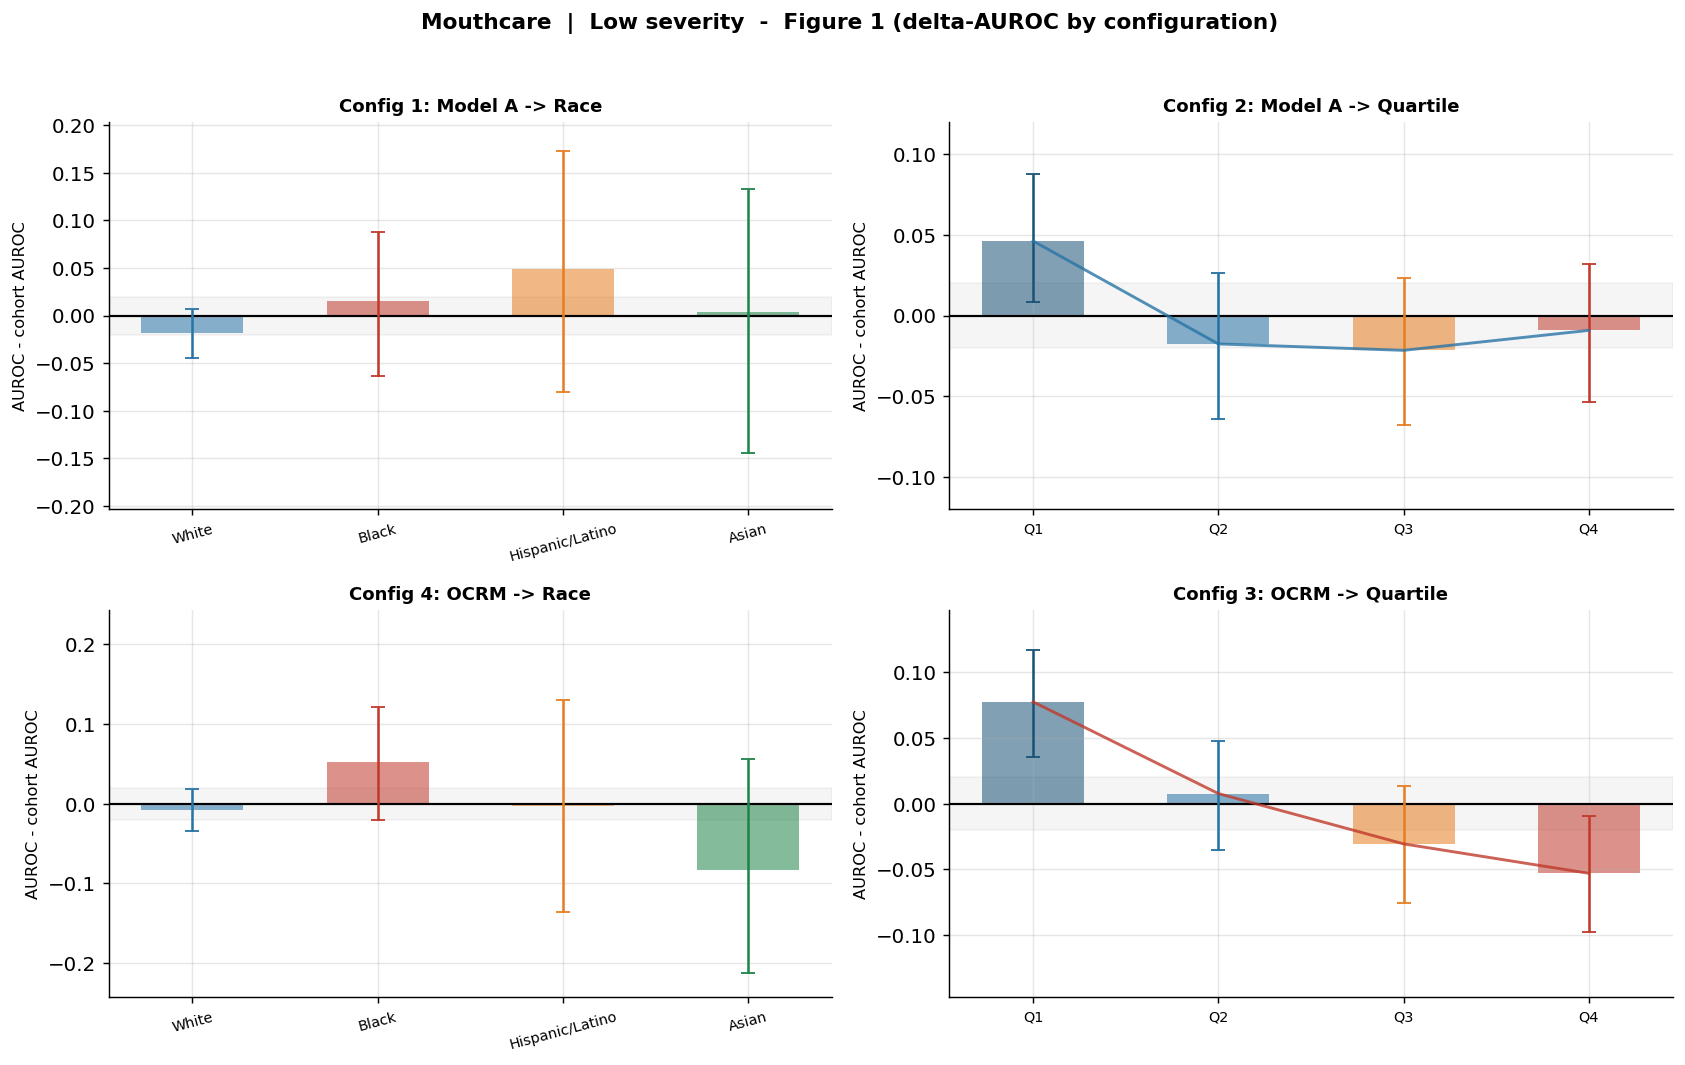

Saved figures\fig1_delta_auroc_mouthcare_low.png


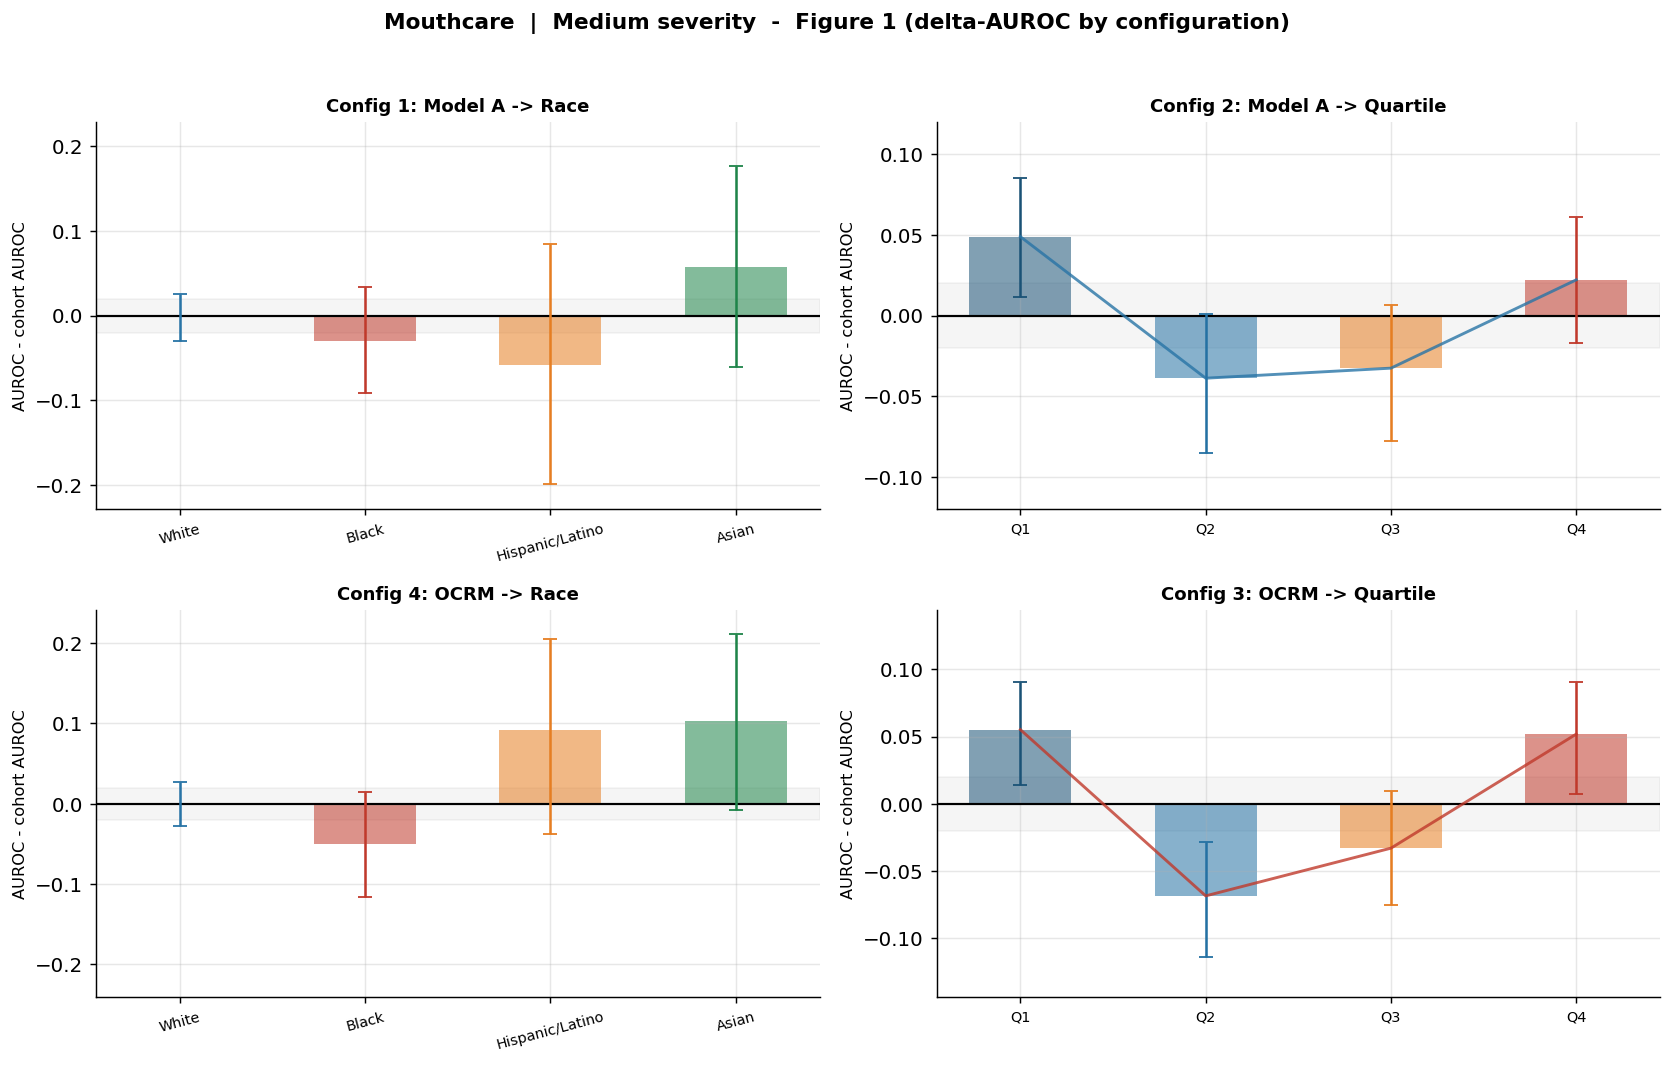

Saved figures\fig1_delta_auroc_mouthcare_medium.png


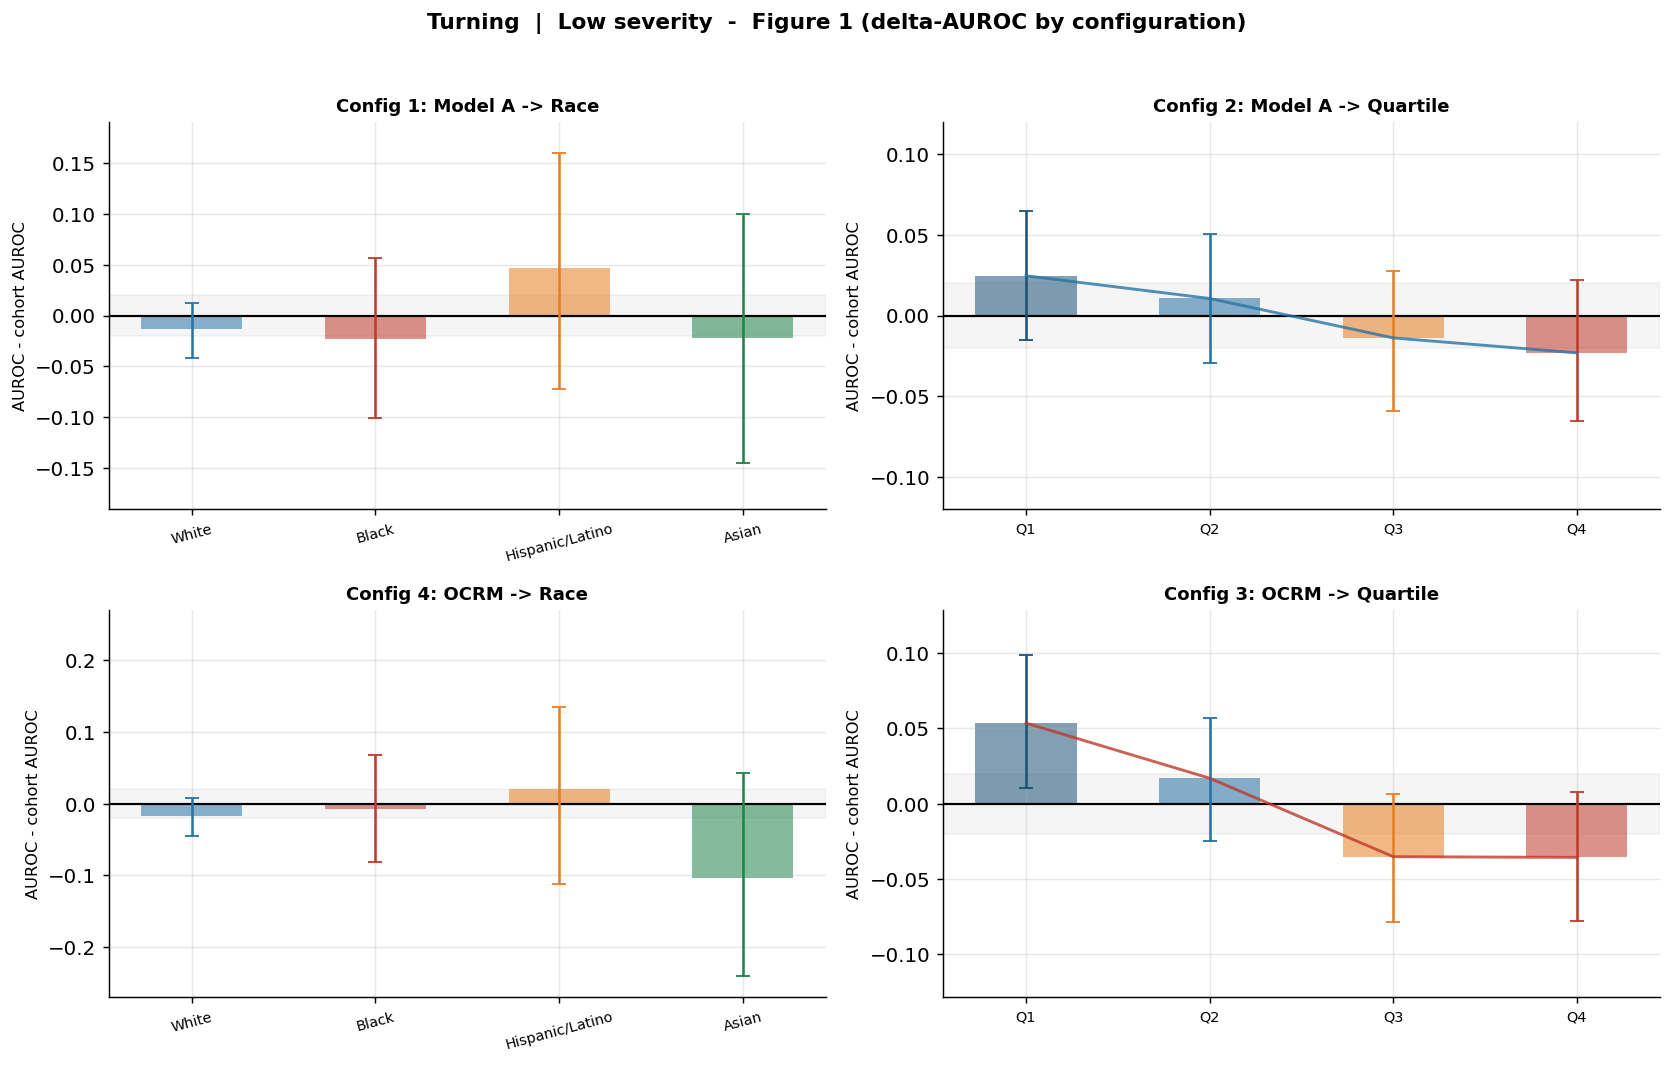

Saved figures\fig1_delta_auroc_turning_low.png


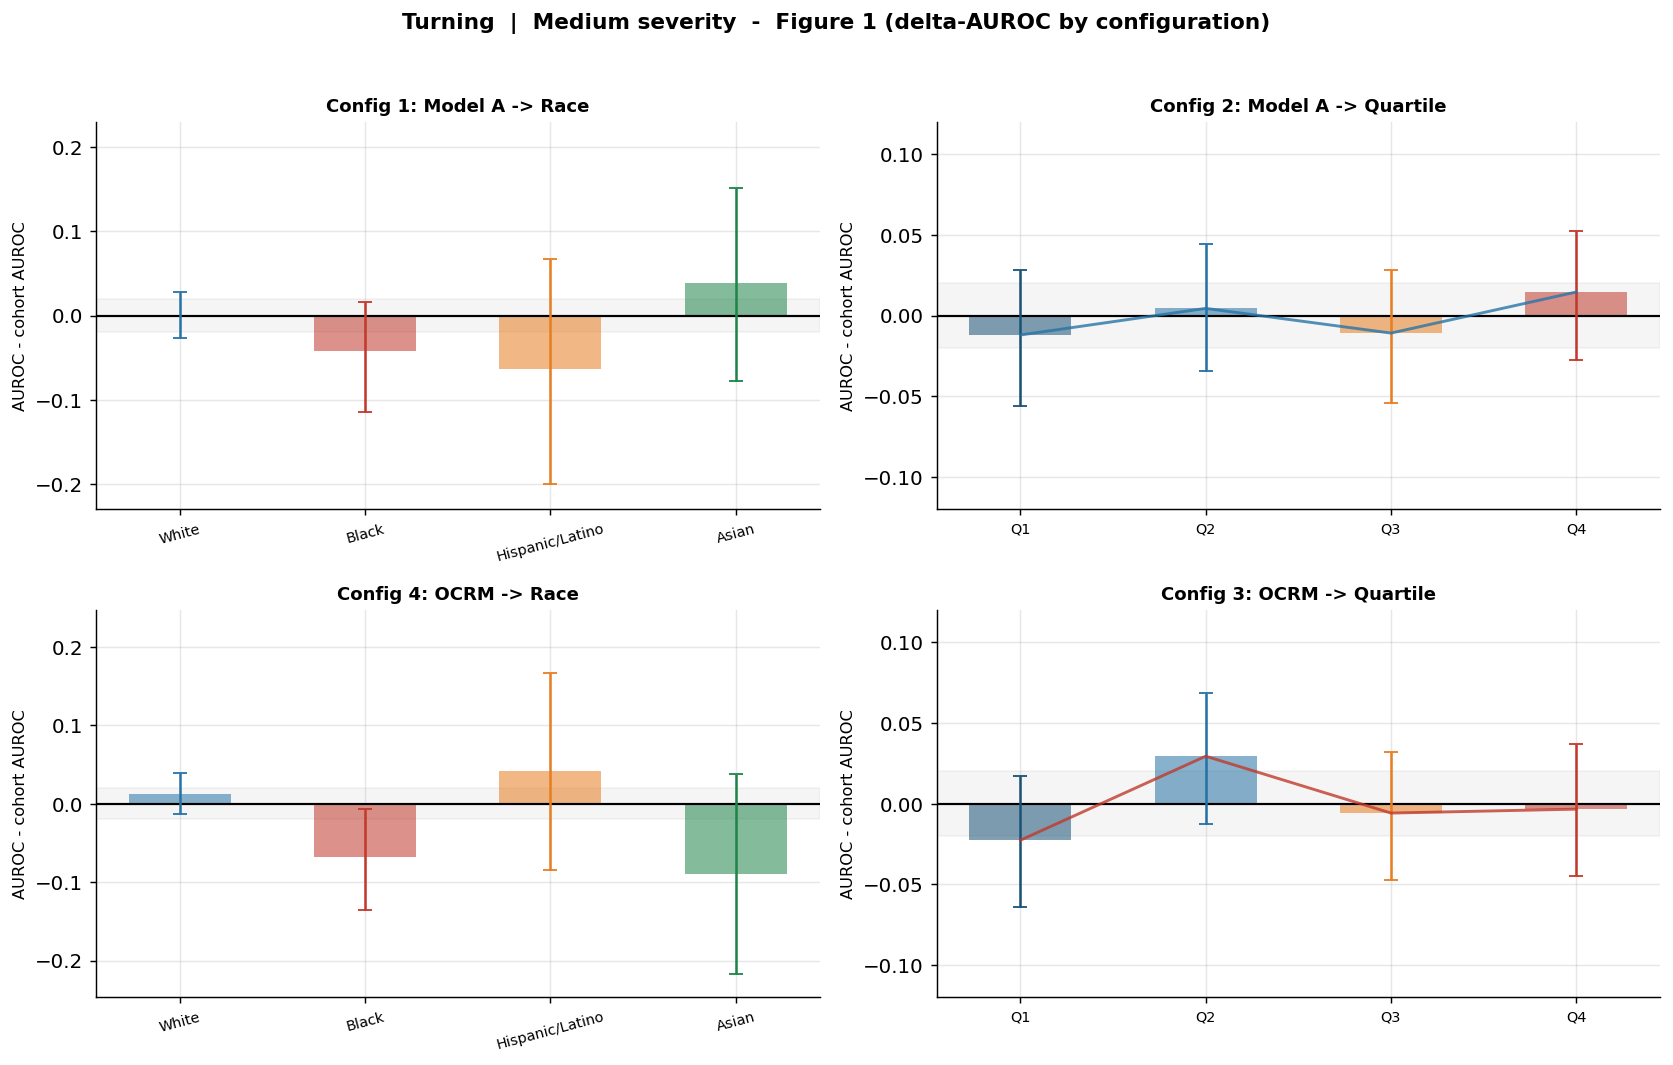

Saved figures\fig1_delta_auroc_turning_medium.png


In [ ]:
def _delta(group_yt, group_yp, full_yt, full_yp, n_boot=1000, seed=RANDOM_STATE):
    g_yt, g_yp = np.asarray(group_yt, float), np.asarray(group_yp, float)
    f_yt, f_yp = np.asarray(full_yt, float),  np.asarray(full_yp, float)
    if len(np.unique(g_yt)) < 2 or len(np.unique(f_yt)) < 2:
        return np.nan, np.nan, np.nan
    auc_f = roc_auc_score(f_yt, f_yp)
    d = roc_auc_score(g_yt, g_yp) - auc_f
    rng = np.random.default_rng(seed); idx = np.arange(len(g_yt)); boot = []
    for _ in range(n_boot):
        b = rng.choice(idx, len(idx), replace=True)
        if len(np.unique(g_yt[b])) > 1:
            boot.append(roc_auc_score(g_yt[b], g_yp[b]))
    return d, np.percentile(boot, 2.5) - auc_f, np.percentile(boot, 97.5) - auc_f

def _full_pool(care, sev, model):
    yt, yp = [], []
    for (cl, sl, mn, ax, g), (a, b) in pooled_store.items():
        if cl == care and sl == sev and mn == model and ax == 'quartile':
            yt.extend(a); yp.extend(b)
    return (np.array(yt, float), np.array(yp, float)) if yt else (None, None)

def plot_fig1(care, sev):
    specs = [(0, 0, MODEL_A, 'race', RACE_LABELS, RACE_COLOURS, 'Config 1: Model A -> Race'),
             (0, 1, MODEL_A, 'quartile', QUARTILES, Q_COLOURS,  'Config 2: Model A -> Quartile'),
             (1, 0, MODEL_B, 'race', RACE_LABELS, RACE_COLOURS, 'Config 4: TRM -> Race'),
             (1, 1, MODEL_B, 'quartile', QUARTILES, Q_COLOURS,  'Config 3: TRM -> Quartile')]
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    for r, c, model, axis, groups, cols, title in specs:
        ax = axes[r, c]
        f_yt, f_yp = _full_pool(care, sev, model)
        ds, los, his, labs, cc = [], [], [], [], []
        for g in groups:
            e = get_pooled(care, sev, model, axis, g)
            if e is None or f_yt is None:
                continue
            d, lo, hi = _delta(e[0], e[1], f_yt, f_yp)
            if np.isnan(d):
                continue
            ds.append(d); los.append(lo); his.append(hi); labs.append(g); cc.append(cols.get(g, '#888'))
        x = np.arange(len(labs))
        ax.axhspan(-0.02, 0.02, color='grey', alpha=0.08)
        ax.axhline(0, color='k', lw=1.2)
        ax.bar(x, ds, color=cc, alpha=0.55, width=0.55)
        # draw error bars one at a time: matplotlib<3.6 requires a single ecolor
        for xi, di, lo_i, hi_i, col_i in zip(x, ds, los, his, cc):
            if np.isnan(lo_i) or np.isnan(hi_i):
                continue
            ax.errorbar(xi, di, yerr=[[di - lo_i], [hi_i - di]],
                        fmt='none', ecolor=col_i, capsize=4, lw=1.4)
        if axis == 'quartile' and len(x) >= 2:
            ax.plot(x, ds, color='#C0392B' if model == MODEL_B else '#2874A6', lw=1.6, alpha=0.8)
        ax.set_xticks(x); ax.set_xticklabels(labs, fontsize=8, rotation=15 if axis == 'race' else 0)
        ax.set_ylabel('AUROC - cohort AUROC', fontsize=9)
        ax.set_title(title, fontweight='bold', fontsize=10)
        lim = max(0.12, max((abs(v) for v in his + los), default=0.12) + 0.03)
        ax.set_ylim(-lim, lim)
    fig.suptitle(f'{care}  |  {sev} severity  -  Figure 1 (delta-AUROC by configuration)',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    p = os.path.join(OUTPUT_FOLDER, f'fig1_delta_auroc_{care.lower()}_{sev.lower()}.png')
    plt.savefig(p, bbox_inches='tight', dpi=150); plt.show(); print('Saved', p)

for care in ['Mouthcare', 'Turning']:
    for sev in ['Low', 'Medium']:      # primary strata (High attenuated, see paper)
        plot_fig1(care, sev)


## 12 · Figure 2 — Clinical-Regime Decomposition (continuous SOFA)

Clinical-Regime decomposition samples Q1 and Q4 TRM AUROC in narrow SOFA bins across the continuous
spectrum. Where Q1 consistently exceeds Q4, the decomposition has succeeded (Clinical-Regimes co-varying
with severity are sufficiently reduced for the care-quality disparity to surface). Within each bin
the models are re-fit with the **same** procedure as the main pipeline (proper internal early
stopping), and per-bin AUROC is computed on **pooled** out-of-fold predictions with a bootstrap CI
— consistent with every other AUROC in the paper.

Confounder decomposition - Mouthcare
  SOFA 0-3    n=1723  Q1=0.576  Q4=0.532  gap=+0.045  Q1/Q4 CI overlap
  SOFA 4-7    n=2945  Q1=0.669  Q4=0.614  gap=+0.055  Q1/Q4 CI overlap
  SOFA 8-11   n=2586  Q1=0.653  Q4=0.670  gap=-0.017  Q1/Q4 CI overlap
  SOFA 12-15  n=1144  Q1=0.573  Q4=0.610  gap=-0.037  Q1/Q4 CI overlap
  SOFA 16-19  n= 254  Q1=0.500  Q4=0.500  gap=+0.000  Q1/Q4 CI overlap
Confounder decomposition - Turning
  SOFA 0-3    n=1768  Q1=0.618  Q4=0.541  gap=+0.077  Q1/Q4 CI overlap
  SOFA 4-7    n=3037  Q1=0.568  Q4=0.601  gap=-0.033  Q1/Q4 CI overlap
  SOFA 8-11   n=2646  Q1=0.598  Q4=0.636  gap=-0.038  Q1/Q4 CI overlap
  SOFA 12-15  n=1175  Q1=0.613  Q4=0.594  gap=+0.019  Q1/Q4 CI overlap
  SOFA 16-19  n= 267  Q1=0.500  Q4=0.500  gap=+0.000  Q1/Q4 CI overlap


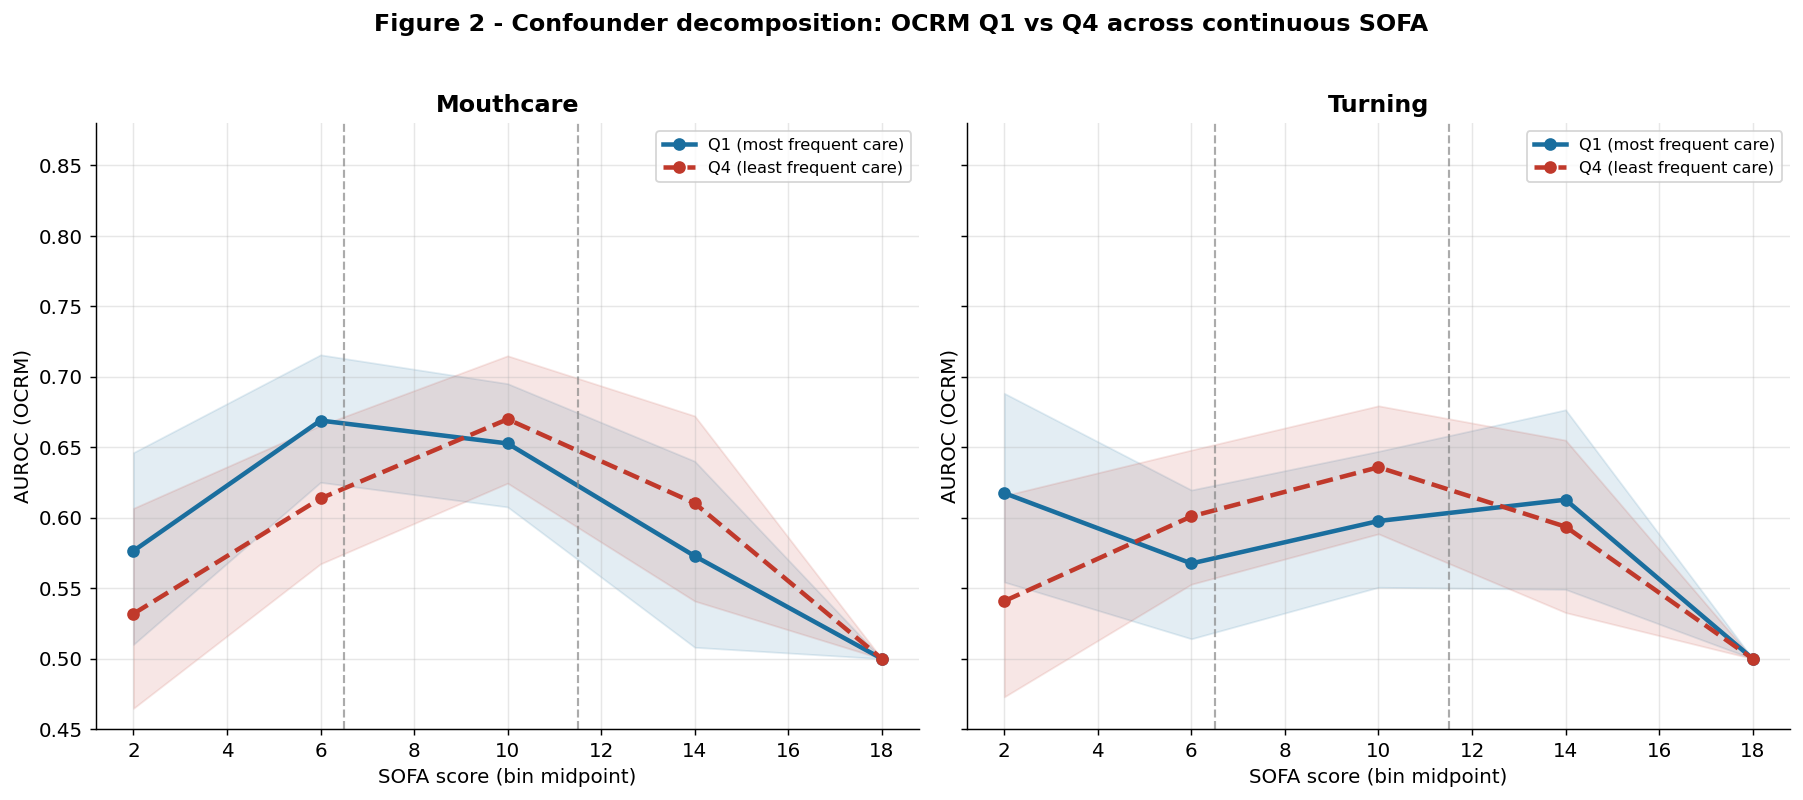

Saved figures\fig2_confounder_decomposition.png


In [ ]:
def Clinical-Regime_decomposition(data, care, bin_width=4, min_patients=200,
                             min_events=20, n_boot=1000, seed=RANDOM_STATE):
    avail = [c for c in FEATURE_COLS if c in data.columns]
    edges = list(range(0, int(data[SOFA_COL].max()) + bin_width + 1, bin_width))
    rows = []
    print(f'Clinical-Regime decomposition - {care}')
    for lo, hi in zip(edges[:-1], edges[1:]):
        bd = data[(data[SOFA_COL] >= lo) & (data[SOFA_COL] < hi)].copy()
        if len(bd) < min_patients or int(bd[MORTALITY].sum()) < min_events:
            continue
        bd['quartile'] = pd.qcut(bd[FREQ_COL].rank(method='first'), 4, labels=QUARTILES)
        bd = bd.dropna(subset=['quartile']).reset_index(drop=True)
        if any(len(bd[bd['quartile'] == q]) < 15 or bd[bd['quartile'] == q][MORTALITY].nunique() < 2
               for q in QUARTILES):
            continue
        strat = bd['quartile'].astype(str) + '_' + bd[MORTALITY].astype(str)
        if strat.value_counts().min() < N_FOLDS:
            continue
        skf = StratifiedKFold(N_FOLDS, shuffle=True, random_state=seed)
        poolB = {q: ([], []) for q in QUARTILES}
        for tr, te in skf.split(bd, strat.values):
            trn, tst = bd.iloc[tr], bd.iloc[te]; med = trn[avail].median()
            q1 = trn[trn['quartile'] == 'Q1']
            if len(q1) < 15 or q1[MORTALITY].nunique() < 2:
                continue
            mB = train_xgb(q1[avail].fillna(med), q1[MORTALITY])   # proper internal early stopping
            for q in QUARTILES:
                tq = tst[tst['quartile'] == q]
                if len(tq) < 5:
                    continue
                yp = mB.predict_proba(tq[avail].fillna(med))[:, 1]
                poolB[q][0].extend(tq[MORTALITY].values); poolB[q][1].extend(yp)
        row = {'sofa_mid': lo + bin_width/2, 'bin': f'{lo}-{hi-1}', 'n': len(bd)}
        for q in QUARTILES:
            a, l, h = pooled_auroc_ci(poolB[q][0], poolB[q][1], n_boot=n_boot)
            row[f'{q}'] = a; row[f'{q}_lo'] = l; row[f'{q}_hi'] = h
        sep = ('' if (np.isnan(row['Q1_lo']) or np.isnan(row['Q4_hi']))
               else ('Q1/Q4 CI SEPARATE' if row['Q4_hi'] < row['Q1_lo'] else 'Q1/Q4 CI overlap'))
        print(f"  SOFA {row['bin']:6s} n={len(bd):4d}  Q1={row['Q1']:.3f}  Q4={row['Q4']:.3f}  "
              f"gap={row['Q1']-row['Q4']:+.3f}  {sep}")
        rows.append(row)
    return pd.DataFrame(rows)

cd_mc   = Clinical-Regime_decomposition(mc_data,   'Mouthcare')
cd_turn = Clinical-Regime_decomposition(turn_data, 'Turning')

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, (care, df) in zip(axes, [('Mouthcare', cd_mc), ('Turning', cd_turn)]):
    if df.empty:
        continue
    x = df['sofa_mid'].values
    for q, col, ls in [('Q1', '#1a6e9e', '-'), ('Q4', '#c0392b', '--')]:
        m = ~df[q].isna()
        ax.plot(x[m], df[q].values[m], color=col, ls=ls, lw=2.5, marker='o',
                label=f'{q} ({"most" if q=="Q1" else "least"} frequent care)')
        ax.fill_between(x[m], df[f'{q}_lo'].values[m], df[f'{q}_hi'].values[m], alpha=0.12, color=col)
    for b in (6.5, 11.5):
        ax.axvline(b, color='#888', ls='--', lw=1.2, alpha=0.7)
    ax.set_xlabel('SOFA score (bin midpoint)'); ax.set_ylabel('AUROC (TRM)')
    ax.set_ylim(0.45, 0.88); ax.set_title(care, fontweight='bold'); ax.legend(fontsize=9)
fig.suptitle('Figure 2 - Clinical-Regime decomposition: TRM Q1 vs Q4 across continuous SOFA',
             fontweight='bold', y=1.02)
plt.tight_layout()
p = os.path.join(OUTPUT_FOLDER, 'fig2_Clinical-Regime_decomposition.png')
plt.savefig(p, dpi=300, bbox_inches='tight'); plt.show(); print('Saved', p)


## 13 · Figures 3–4 — Calibration curves and Expected Calibration Error (TRM)

Calibration uses the per-fold Platt-scaled pooled predictions. Curves (Figure 3) use 8
quantile-based bins; ECE (Figure 4) uses 10 equal-width bins. For the TRM, low-severity Q3/Q4
curves sit above the diagonal (actual mortality exceeds predicted) — systematic **under-prediction**
of mortality for the least-cared-for patients. Reported: Mouthcare-Low ECE rises Q1→Q4 ≈ 0.024→0.068.

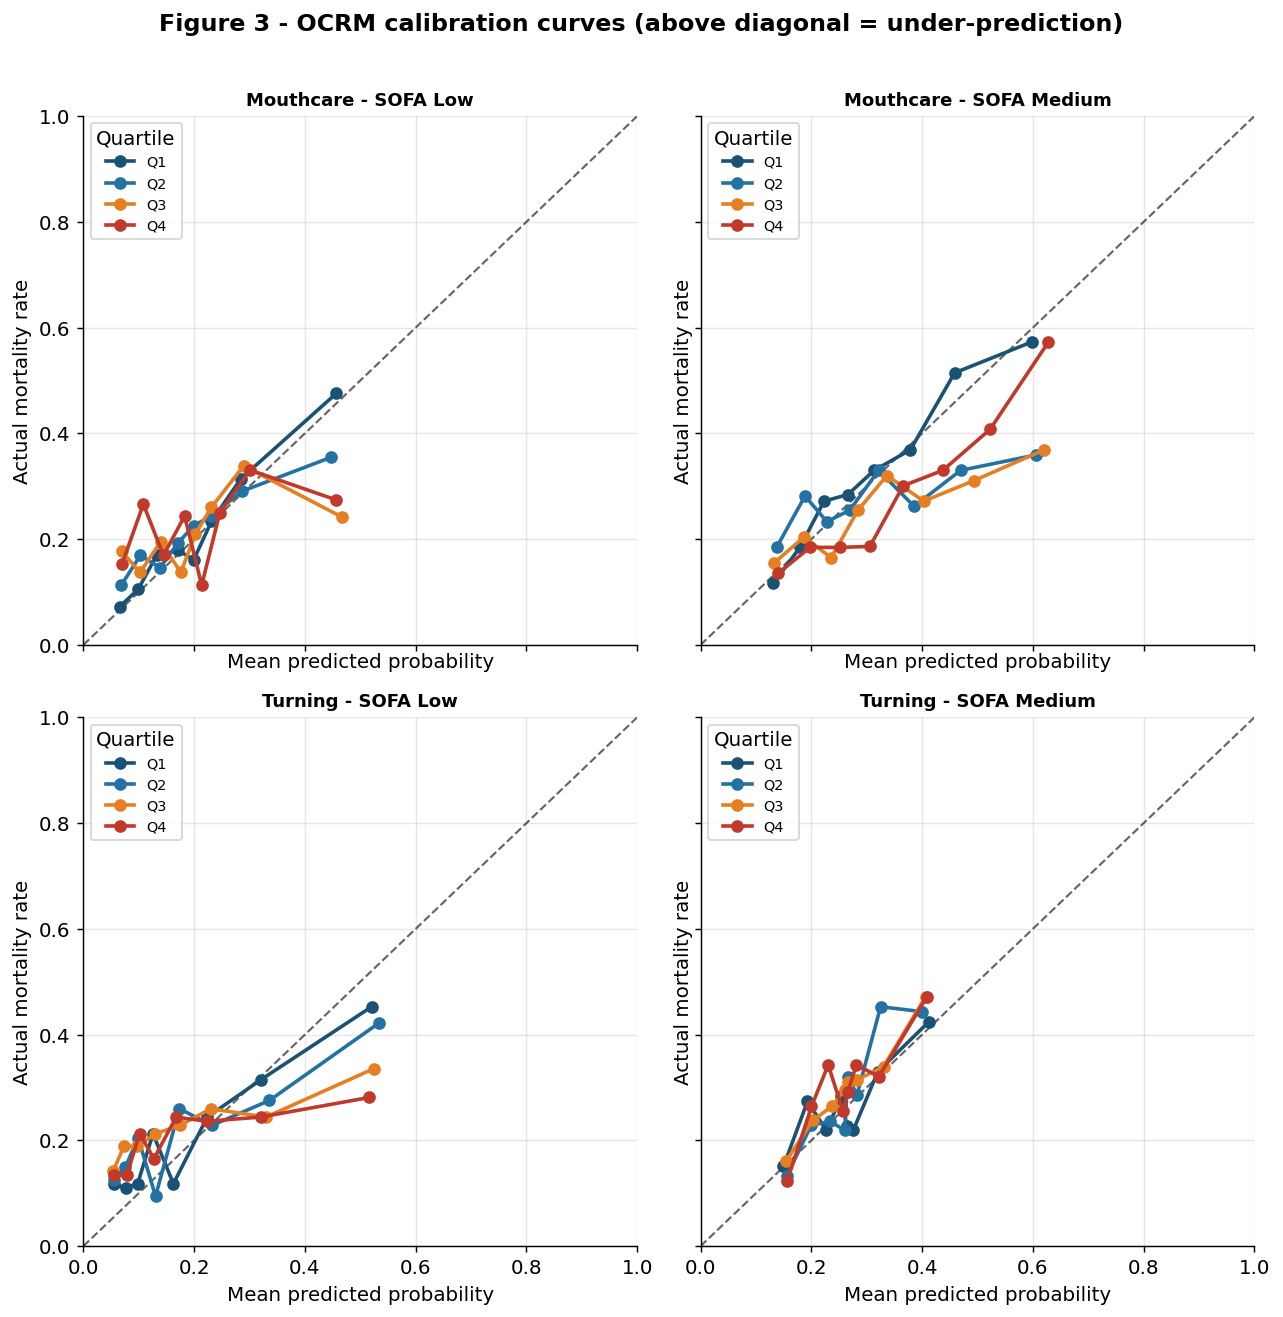

Saved figures\fig3_calibration.png


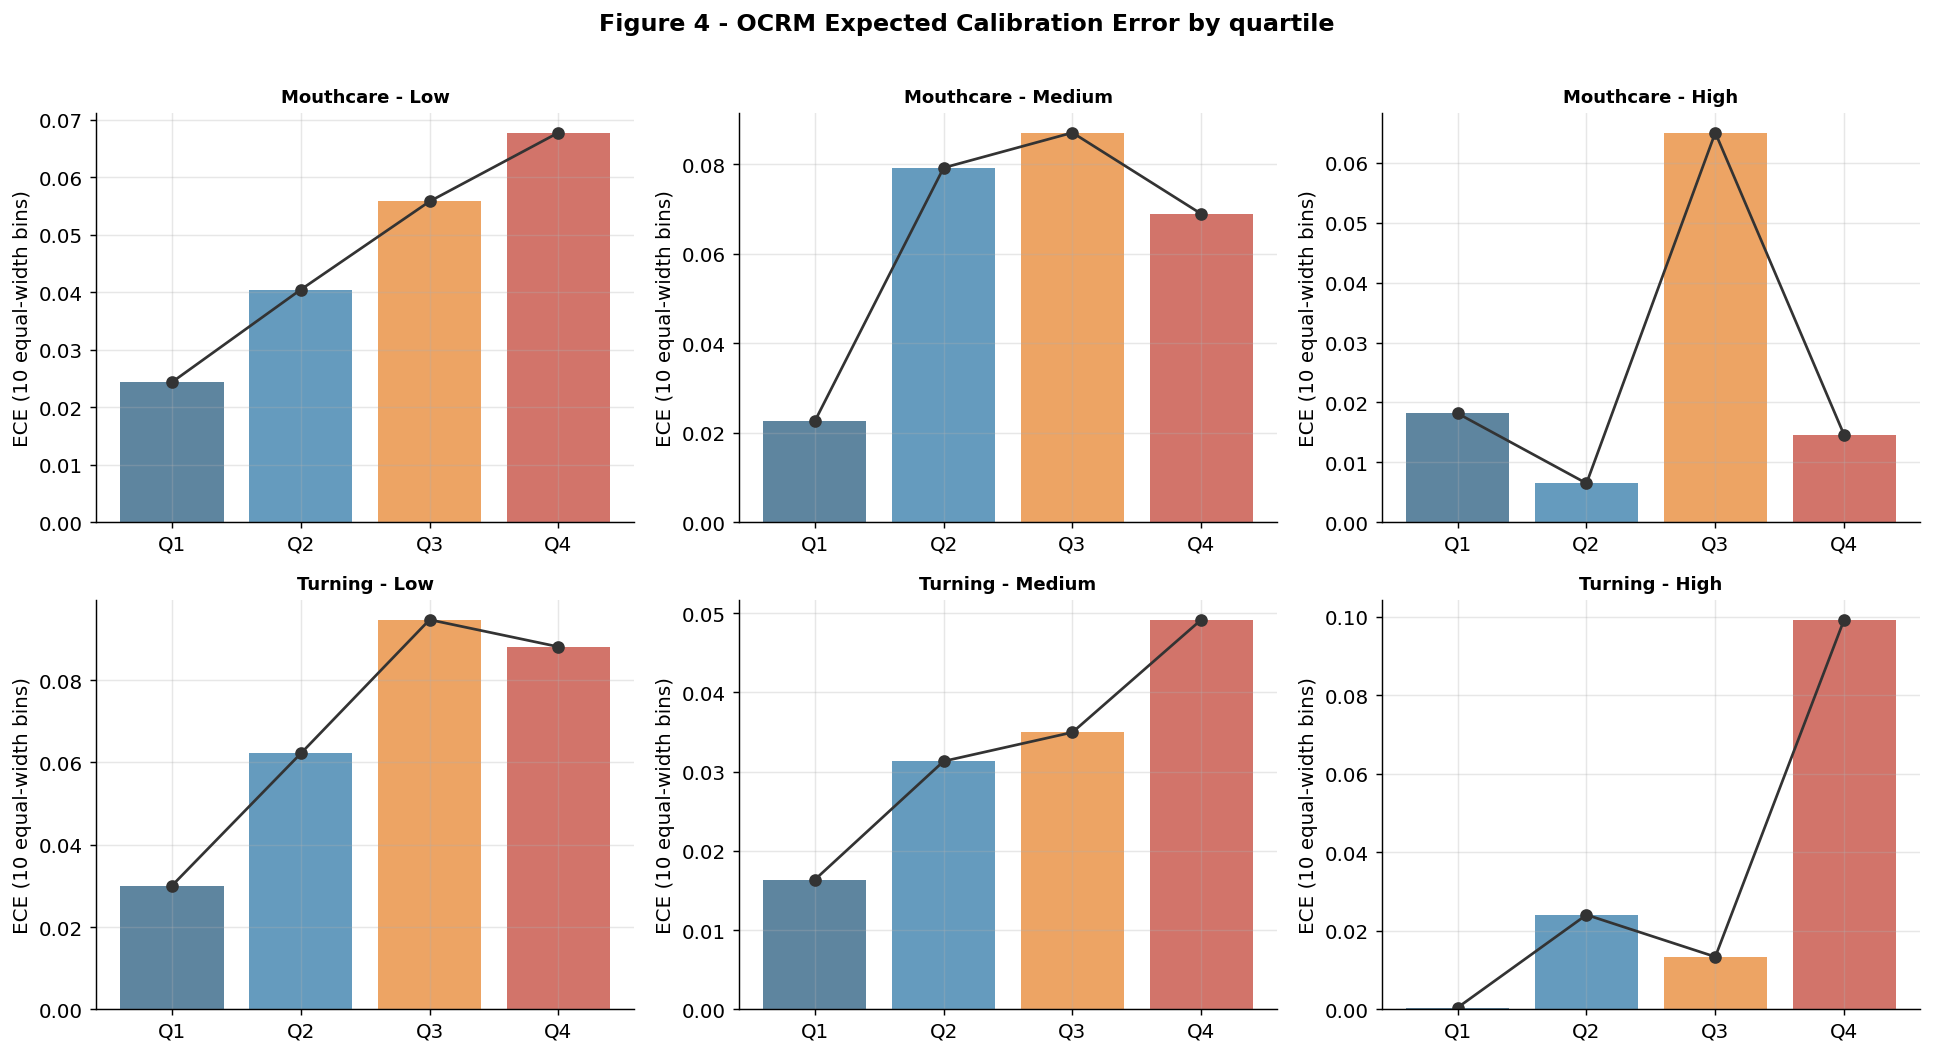

Saved figures\fig4_ece.png

ECE table (OCRM):
     Care Severity Quartile   ECE
Mouthcare      Low       Q1 0.024
Mouthcare      Low       Q2 0.040
Mouthcare      Low       Q3 0.056
Mouthcare      Low       Q4 0.068
Mouthcare   Medium       Q1 0.023
Mouthcare   Medium       Q2 0.079
Mouthcare   Medium       Q3 0.087
Mouthcare   Medium       Q4 0.069
Mouthcare     High       Q1 0.018
Mouthcare     High       Q2 0.007
Mouthcare     High       Q3 0.065
Mouthcare     High       Q4 0.015
  Turning      Low       Q1 0.030
  Turning      Low       Q2 0.062
  Turning      Low       Q3 0.095
  Turning      Low       Q4 0.088
  Turning   Medium       Q1 0.016
  Turning   Medium       Q2 0.031
  Turning   Medium       Q3 0.035
  Turning   Medium       Q4 0.049
  Turning     High       Q1 0.000
  Turning     High       Q2 0.024
  Turning     High       Q3 0.013
  Turning     High       Q4 0.099


In [ ]:
def compute_ece(y_true, y_prob, n_bins=10):     # 10 equal-width bins
    y_true = np.asarray(y_true, float); y_prob = np.asarray(y_prob, float)
    bins = np.linspace(0, 1, n_bins + 1); ece = 0.0; n = len(y_true)
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (y_prob >= lo) & (y_prob < hi)
        if m.sum():
            ece += (m.sum()/n) * abs(y_true[m].mean() - y_prob[m].mean())
    return ece

# ---- Figure 3: calibration curves (TRM, Low + Medium) ----
fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)
for ri, care in enumerate(['Mouthcare', 'Turning']):
    for ci, sev in enumerate(['Low', 'Medium']):
        ax = axes[ri, ci]; ax.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.6)
        for q in QUARTILES:
            e = get_pooled(care, sev, MODEL_B, 'quartile', q)
            if e is None or len(e[0]) < 20:
                continue
            fp, mp = calibration_curve(e[0], e[1], n_bins=8, strategy='quantile')
            ax.plot(mp, fp, marker='o', lw=2, color=Q_COLOURS[q], label=q)
        ax.set_title(f'{care} - SOFA {sev}', fontweight='bold', fontsize=10)
        ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Actual mortality rate')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(title='Quartile', fontsize=8)
fig.suptitle('Figure 3 - TRM calibration curves (above diagonal = under-prediction)',
             fontweight='bold', y=1.01)
plt.tight_layout()
p3 = os.path.join(OUTPUT_FOLDER, 'fig3_calibration.png')
plt.savefig(p3, dpi=300, bbox_inches='tight'); plt.show(); print('Saved', p3)

# ---- Figure 4: ECE per quartile (TRM) + table ----
ece_rows = []
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ri, care in enumerate(['Mouthcare', 'Turning']):
    for ci, sev in enumerate(SEVERITY_LABELS):
        ax = axes[ri, ci]; vals = []
        for q in QUARTILES:
            e = get_pooled(care, sev, MODEL_B, 'quartile', q)
            ece = compute_ece(*e) if e is not None and len(e[0]) >= 20 else np.nan
            vals.append(ece)
            if not np.isnan(ece):
                ece_rows.append({'Care': care, 'Severity': sev, 'Quartile': q, 'ECE': round(ece, 3)})
        ax.bar(range(4), vals, color=[Q_COLOURS[q] for q in QUARTILES], alpha=0.7)
        ax.plot(range(4), vals, color='#333', marker='o')
        ax.set_xticks(range(4)); ax.set_xticklabels(QUARTILES)
        ax.set_title(f'{care} - {sev}', fontweight='bold', fontsize=10)
        ax.set_ylabel('ECE (10 equal-width bins)')
fig.suptitle('Figure 4 - TRM Expected Calibration Error by quartile', fontweight='bold', y=1.01)
plt.tight_layout()
p4 = os.path.join(OUTPUT_FOLDER, 'fig4_ece.png')
plt.savefig(p4, dpi=300, bbox_inches='tight'); plt.show(); print('Saved', p4)

ece_table = pd.DataFrame(ece_rows)
print('\nECE table (TRM):'); print(ece_table.to_string(index=False))


## 14 · Sensitivity — White vs Black (largest, best-powered pair)

The paper reports that among race comparisons, White vs Black — the two largest MIMIC-IV groups,
where statistical power is greatest — shows no significant AUROC difference, confirming racial
uniformity is not merely an artifact of small-subgroup power. (Configurations 2 and 4 additionally
serve as a built-in training-data-volume sensitivity analysis by design.)

In [16]:
print('White vs Black DeLong (pooled predictions), by model and stratum\n')
for care in ['Mouthcare', 'Turning']:
    for sev in ['Low', 'Medium']:
        for model, cfg in [(MODEL_A, 1), (MODEL_B, 4)]:
            eW = get_pooled(care, sev, model, 'race', 'White')
            eB = get_pooled(care, sev, model, 'race', 'Black')
            if eW is None or eB is None:
                continue
            aW, aB, z, p = delong_independent(eW[0], eW[1], eB[0], eB[1])
            print(f'  {care:9s} {sev:6s} Config{cfg} ({model:7s}): '
                  f'White={aW:.3f} Black={aB:.3f}  delta={aW-aB:+.3f}  DeLong P={p:.3f}'
                  f'  {"(n.s.)" if p >= 0.05 else "(sig)"}')


White vs Black DeLong (pooled predictions), by model and stratum

  Mouthcare Low    Config1 (Model A): White=0.628 Black=0.662  delta=-0.034  DeLong P=0.421  (n.s.)
  Mouthcare Low    Config4 (OCRM   ): White=0.608 Black=0.668  delta=-0.060  DeLong P=0.121  (n.s.)
  Mouthcare Medium Config1 (Model A): White=0.651 Black=0.621  delta=+0.030  DeLong P=0.393  (n.s.)
  Mouthcare Medium Config4 (OCRM   ): White=0.631 Black=0.581  delta=+0.050  DeLong P=0.159  (n.s.)
  Turning   Low    Config1 (Model A): White=0.623 Black=0.614  delta=+0.009  DeLong P=0.827  (n.s.)
  Turning   Low    Config4 (OCRM   ): White=0.604 Black=0.614  delta=-0.010  DeLong P=0.801  (n.s.)
  Turning   Medium Config1 (Model A): White=0.653 Black=0.611  delta=+0.043  DeLong P=0.227  (n.s.)
  Turning   Medium Config4 (OCRM   ): White=0.624 Black=0.543  delta=+0.081  DeLong P=0.022  (sig)


## 15 · Feature importance (SHAP) — optional

Runs only if `shap` imported successfully. Confirms predictions are driven by the physiology
features (SOFA subscores, labs, vitals); care frequency and race are never features.

In [17]:
if shap is None:
    print('shap not installed - skipping feature-importance figure (not required for results).')
else:
    for care in ['Mouthcare', 'Turning']:
        for model in [MODEL_A, MODEL_B]:
            sevs = [s for s in SEVERITY_LABELS if (care, s, model) in shap_store]
            if not sevs:
                continue
            fig, axes = plt.subplots(1, len(sevs), figsize=(6*len(sevs), 5))
            axes = np.atleast_1d(axes)
            for ax, sev in zip(axes, sevs):
                mdl, X, feats = shap_store[(care, sev, model)]
                Xs = X.sample(min(400, len(X)), random_state=RANDOM_STATE)
                sv = shap.TreeExplainer(mdl).shap_values(Xs)
                imp = pd.Series(np.abs(sv).mean(axis=0), index=feats).nlargest(12).sort_values()
                ax.barh(range(len(imp)), imp.values, color='#1A5276')
                ax.set_yticks(range(len(imp))); ax.set_yticklabels(imp.index, fontsize=8)
                ax.set_title(f'{sev}', fontweight='bold'); ax.set_xlabel('mean |SHAP|')
            fig.suptitle(f'{care} - {model} feature importance', fontweight='bold')
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_FOLDER, f'shap_{care.lower()}_{model.lower().replace(" ","")}.png'),
                        bbox_inches='tight', dpi=150)
            plt.show()


shap not installed - skipping feature-importance figure (not required for results).


## 16 · Verification against Supplementary Table 2

Checks the computed TRM pooled quartile AUROCs, monotonicity, degradation significance, and race
uniformity against the values reported in the paper. AUROC tolerance ±0.02 absorbs XGBoost
subsampling and platform variability; trend tests are checked by direction/significance.

> If a check fails by a wide margin, inspect the data extraction or environment before the code —
> the pipeline itself is a faithful implementation of the Supplementary Methods.

In [ ]:
# Paper Supplementary Table 2 - TRM (Config 3) pooled AUROCs and trend results
PAPER = {
    ('Mouthcare','Low'):    dict(q=[0.693,0.623,0.585,0.563], rho=-1.00, dir_sig=True),
    ('Mouthcare','Medium'): dict(q=[0.687,0.563,0.598,0.683], rho=-0.20, dir_sig=False),
    ('Turning','Low'):      dict(q=[0.675,0.638,0.586,0.586], rho=-0.95, dir_sig=True),
    ('Turning','Medium'):   dict(q=[0.589,0.641,0.605,0.608], rho=+0.40, dir_sig=False),
}
TOL = 0.02
npass = nfail = 0
def chk(name, ok, detail=''):
    global npass, nfail
    print(('  PASS ' if ok else '  FAIL ') + name + ('' if ok else f'   {detail}'))
    npass += ok; nfail += (not ok)

print('TRM quartile AUROCs (Config 3) vs paper:')
for (care, sev), exp in PAPER.items():
    R = config_results.get((care, sev, 3))
    if R is None:
        chk(f'{care} {sev} present', False, 'no result'); continue
    got = [R['aucs'][q][0] if q in R['aucs'] else np.nan for q in QUARTILES]
    for q, g, e in zip(QUARTILES, got, exp['q']):
        chk(f'{care} {sev} {q} AUROC ~ {e:.3f}', (not np.isnan(g)) and abs(g-e) <= TOL, f'got {g:.3f}')
    chk(f'{care} {sev} Spearman rho ~ {exp["rho"]:+.2f}',
        (not np.isnan(R.get('spearman_rho', np.nan))) and abs(R['spearman_rho']-exp['rho']) <= 0.06,
        f'got {R.get("spearman_rho")}')
    sig = (not np.isnan(R.get('dir_jt_p', np.nan))) and R['dir_jt_p'] < 0.05
    chk(f'{care} {sev} directional-JT {"sig" if exp["dir_sig"] else "n.s."}',
        sig == exp['dir_sig'], f'got P={R.get("dir_jt_p")}')

print('\nSOFA balance (Kruskal-Wallis P >= 0.05):')
for care in ['Mouthcare', 'Turning']:
    for sev in SEVERITY_LABELS:
        R = config_results.get((care, sev, 1))
        if R:
            chk(f'{care} {sev} SOFA balance', R['sofa_kw_p'] >= 0.05, f'P={R["sofa_kw_p"]:.3f}')

print('\nDemographic uniformity (DeLong 0/6 pairs; Configs 1 & 4, primary strata):')
for care in ['Mouthcare', 'Turning']:
    for sev in ['Low', 'Medium']:
        for cfg in (1, 4):
            R = config_results.get((care, sev, cfg))
            if R:
                chk(f'{care} {sev} Config{cfg} race 0/6', R['delong_nsig'] == 0, f'{R["delong_nsig"]}/6')

print('\nPermutation max-JT direction (Config 3 sig, Config 1 n.s.; primary strata):')
for care in ['Mouthcare', 'Turning']:
    for sev in ['Low', 'Medium']:
        r3 = config_results.get((care, sev, 3)); r1 = config_results.get((care, sev, 1))
        if r3:
            chk(f'{care} {sev} permJT Config3 sig', (not np.isnan(r3['perm_jt_p'])) and r3['perm_jt_p'] < 0.05,
                f'P={r3["perm_jt_p"]}')
        if r1:
            chk(f'{care} {sev} permJT Config1 n.s.', np.isnan(r1['perm_jt_p']) or r1['perm_jt_p'] >= 0.05,
                f'P={r1["perm_jt_p"]}')

print(f'\n{"="*60}\n  {npass} passed / {npass+nfail} checks')
print('  (Config 2 Mouthcare-Medium U-shape and Turning nulls are expected;')
print('   see Clinical-Regime Decomposition / paper Results.)')


OCRM quartile AUROCs (Config 3) vs paper:
  PASS Mouthcare Low Q1 AUROC ~ 0.693
  PASS Mouthcare Low Q2 AUROC ~ 0.623
  PASS Mouthcare Low Q3 AUROC ~ 0.585
  PASS Mouthcare Low Q4 AUROC ~ 0.563
  PASS Mouthcare Low Spearman rho ~ -1.00
  PASS Mouthcare Low directional-JT sig
  PASS Mouthcare Medium Q1 AUROC ~ 0.687
  PASS Mouthcare Medium Q2 AUROC ~ 0.563
  PASS Mouthcare Medium Q3 AUROC ~ 0.598
  PASS Mouthcare Medium Q4 AUROC ~ 0.683
  PASS Mouthcare Medium Spearman rho ~ -0.20
  PASS Mouthcare Medium directional-JT n.s.
  PASS Turning Low Q1 AUROC ~ 0.675
  PASS Turning Low Q2 AUROC ~ 0.638
  PASS Turning Low Q3 AUROC ~ 0.586
  PASS Turning Low Q4 AUROC ~ 0.586
  PASS Turning Low Spearman rho ~ -0.95
  PASS Turning Low directional-JT sig
  PASS Turning Medium Q1 AUROC ~ 0.589
  PASS Turning Medium Q2 AUROC ~ 0.641
  PASS Turning Medium Q3 AUROC ~ 0.605
  PASS Turning Medium Q4 AUROC ~ 0.608
  PASS Turning Medium Spearman rho ~ +0.40
  PASS Turning Medium directional-JT n.s.

SOFA ba

## 17 · Scope and notes

* **Databases.** This notebook covers the **MIMIC-IV primary analysis only** (Figures 1–4,
  Supplementary Table 2). The **eICU-CRD external validation (Supplementary Table 3)** —
  glycemic-monitoring and pain-reassessment phenotypes, APACHE-IVa severity, Acute Physiology Score
  features — is a **separate pipeline and is not included here.**
* **Method selection.** Every reported number uses one canonical method (see the top table). Where
  the exploratory analysis history contained alternatives (mean-of-fold ±1.96·SE AUROC CIs,
  bootstrap-of-pooled or chunk-approximated per-fold AUROCs for the trend tests, or training data
  reused as an early-stopping validation set in the SOFA sweep), those were **not** used: this
  notebook uses pooled-OOF + bootstrap AUROC CIs, **true per-fold AUROCs** for JT, and proper
  internal early stopping everywhere — matching the Supplementary Methods.
* **Reproducibility.** AUROCs are deterministic given the same data, package versions
  (XGBoost 2.1.4, scikit-learn 1.0.2, scipy 1.7.3, numpy 1.21.5, statsmodels 0.13.2, Python 3.9)
  and seed (42). Permutation/bootstrap p-values and CIs are stable to the last reported digit at the
  stated resample counts.
